In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Minimizer, Parameters
import sys
import pylab as py
import pandas as pd
import csv
import matplotlib.dates as mdates
from scipy import optimize, stats
from importlib import reload
import DataAnalysis.basic_functions as bf
import DataAnalysis.mod_expo_fit_functions as modf
import DataAnalysis.bi_fit_functions as bi_fit
import DataAnalysis.pulser_fit_functions as pf
import DataAnalysis.plot_functions as plotf
from scipy.signal import find_peaks

sys.path.append('/Users/arleeshelby/ManitobaWork_1374/pyNab/src')
import nabPy as Nab

In [2]:
with open('/Users/arleeshelby/Downloads/Runparameters10_10_12_03.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [3]:
metadata

,runnumber,runstarttime,rundescription,HV,Max HV leakage,LDET armor,LDET bias,LDET leakage,UDET armor,UDET ring,UDET bias,UDET leakage,SNS power,Beamline status,UDET,MAIN,Max bore pressure,ExB voltage,errorcode
0,9037,1764353934000,Pulser test run while UDET is ramping down,0.0,0.238834,127.496351,300.0,36.809110,134.197349,120.003505,300.0,0.007683,0.0,0.0,22.0,86.0,1.042000e-08,0.000000,0
1,9036,1764350278000,"Standard source run (2xCd, 3xBi) with standard...",27.0,0.238834,129.781257,300.0,35.355400,134.208679,120.001895,300.0,0.007486,0.0,0.0,137.0,137.0,9.263000e-09,-1999.000000,0
2,9035,1764347688000,"Standard source run (2xCd, 3xBi) with standard...",27.0,0.238834,129.833230,300.0,35.322960,134.213279,120.002581,300.0,0.007637,0.0,0.0,137.0,137.0,9.255000e-09,-1999.000000,0
3,9034,1764343307000,Pulser test run,27.0,0.238834,129.856713,300.0,35.332800,134.218774,120.004212,300.0,0.008844,0.0,0.0,137.0,137.0,9.255000e-09,-1999.000000,0
4,9033,1764306368000,"Standard source run (2xCd, 3xBi) while reducin...",27.0,1.663082,132.818064,300.0,35.455730,136.843647,120.265396,300.0,0.017065,0.0,0.0,137.0,137.0,9.322000e-09,-1999.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,8593,1760110661000,DAQ Testing,0.0,0.035370,129.954557,300.0,35.930090,134.425119,120.008237,300.0,0.007492,1810.0,0.0,110.0,137.0,1.163000e-08,-1499.473684,0
444,8592,1760110375000,DAQ Testing,0.0,0.035370,129.934101,300.0,35.943170,134.423998,120.024702,300.0,0.007522,1810.0,0.0,110.0,137.0,1.168000e-08,-1499.518519,0
445,8591,1760109105000,DAQ Testing,0.0,0.035370,129.886951,300.0,35.989980,134.426842,119.996476,300.0,0.007519,1810.0,0.0,110.0,137.0,1.179000e-08,-1499.434783,0
446,8590,1760070041000,"ExB study, ExB -1.5kV, LDET -50V",25.0,0.035370,129.945280,50.0,0.077515,134.431804,119.999043,300.0,0.007711,1803.0,2.0,110.0,110.0,1.490000e-08,-1499.212073,0


In [4]:
metadata.loc[metadata['runnumber']==8660]['UDET ring']

376    119.998569
Name: UDET ring, dtype: float64

In [5]:
run_numbers = list(np.arange(8622,8633)) + list(np.arange(8635,8638)) + list(np.arange(8643,8660)) + list(np.arange(8681,8695)) + list(np.arange(8696,8700)) + list(np.arange(8704,8714)) + list(np.arange(8715,8722)) + list(np.arange(8824,8833))+list(np.arange(8834,8836)) + list(np.arange(8837,8851)) + list(np.arange(8853,8866))

In [6]:
UDETdata, UDETtime = bf.get_energy_time_data(run_numbers,'UDET')
LDETdata, LDETtime = bf.get_energy_time_data(run_numbers,'LDET')

In [7]:
UDETenergy = bf.get_energy(run_numbers,UDETdata)
LDETenergy = bf.get_energy(run_numbers,LDETdata)

In [8]:
UDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='UDET')
LDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='LDET')

In [9]:
UDETenergy_pulser = bf.get_energy(run_numbers,UDETdata_pulser)
LDETenergy_pulser = bf.get_energy(run_numbers,LDETdata_pulser)

In [10]:
bin_edges = UDETdata[8715]['bin_edges']['0']['37']
bin_edges_pulser = UDETdata_pulser[8622]['bin_edges']['0']['60']
bin_edges_pulser112 = UDETdata_pulser[8622]['bin_edges']['0']['pulser BC 112']

In [11]:
def get_low_gain_cal(out,run):
    peak1, peak2, peak3 = out[run][1]['cen1']['value'],out[run][1]['cen2']['value'],out[run][1]['cen3']['value']
    peak1_err, peak2_err, peak3_err = out[run][1]['cen1']['error'],out[run][1]['cen2']['error'],out[run][1]['cen3']['error']
    
    peak4, peak5, peak6 = out[run][2]['cen1']['value'],out[run][2]['cen2']['value'],out[run][2]['cen3']['value']
    peak4_err, peak5_err, peak6_err = out[run][2]['cen1']['error'],out[run][2]['cen2']['error'],out[run][2]['cen3']['error']
    
    params = Parameters()
    params.add('m', value=3)
    params.add('b', value=0)
    outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values[2:]),
                           np.array([peak1, peak2, peak3,
                                     peak4, peak5, peak6]),
                           np.array([peak1_err, peak2_err, peak3_err,
                                     peak4_err, peak5_err, peak6_err]))
    return outr

In [12]:
def get_low_gain_cal_all(out,run):
    peaka, peakb = out[run][0]['cen1']['value'],out[run][0]['cen2']['value']
    peaka_err, peakb_err = out[run][0]['cen1']['error'],out[run][0]['cen2']['error']
    
    peak1, peak2, peak3 = out[run][1]['cen1']['value'],out[run][1]['cen2']['value'],out[run][1]['cen3']['value']
    peak1_err, peak2_err, peak3_err = out[run][1]['cen1']['error'],out[run][1]['cen2']['error'],out[run][1]['cen3']['error']
    
    peak4, peak5, peak6 = out[run][2]['cen1']['value'],out[run][2]['cen2']['value'],out[run][2]['cen3']['value']
    peak4_err, peak5_err, peak6_err = out[run][2]['cen1']['error'],out[run][2]['cen2']['error'],out[run][2]['cen3']['error']
    
    params = Parameters()
    params.add('m', value=3)
    params.add('b', value=0)
    outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values),
                           np.array([peaka,peakb,
                                     peak1, peak2, peak3,
                                     peak4, peak5, peak6]),
                           np.array([peaka_err, peakb_err,
                                     peak1_err, peak2_err, peak3_err,
                                     peak4_err, peak5_err, peak6_err]))
    return outr

In [184]:
keys = list(UDETenergy.keys())
for i in range(len(keys)):
    try:
        UDETenergy[keys[i]]['9']
        print(keys[i])
    except Exception as e:
        continue

8631
8839


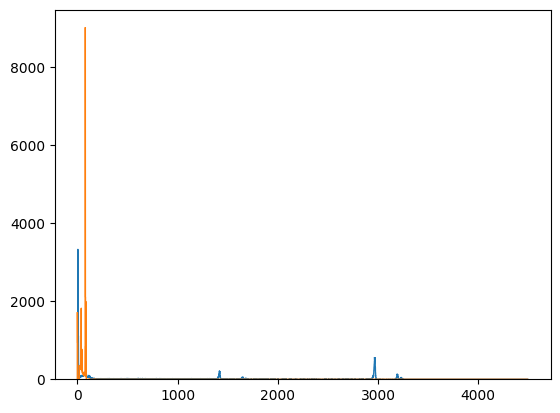

In [508]:
plt.stairs(UDETenergy[8626]['88'],bin_edges)
plt.stairs(UDETenergy[8626]['91'],bin_edges)
# plt.xlim(1000,2000)

In [69]:
import json

In [70]:
with open('8626_91_h.json', 'r') as file:
    d = json.load(file)

In [137]:
with open('8685_91_h.json', 'r') as file:
    d = json.load(file)

In [146]:
with open('8837_91_h.json', 'r') as file:
    d = json.load(file)

In [79]:
dd = {}
dd[8626] = {}
dd[8626]['91'] = d['8626']['91']

In [138]:
dd[8685] = {}
dd[8685]['91'] = d['8685']['91']

In [148]:
dd[8837] = {}
dd[8837]['91'] = d['8837']['91']

In [74]:
b = np.arange(0,4500,0.25)

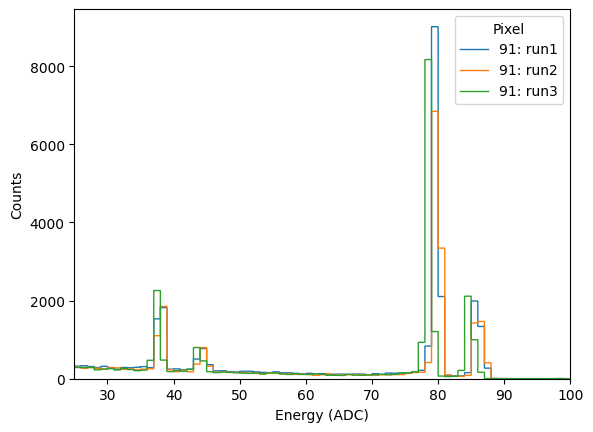

In [145]:
test_runs = [8626,8685,8837]
for i in range(len(test_runs)):
    plt.stairs(UDETenergy[test_runs[i]]['91'],bin_edges,label = '91: run%d'%(i+1))

# plt.stairs(UDETenergy[8718]['99'],bin_edges,label = '99')
plt.xlim(25,100)
# plt.ylim(0,1700)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

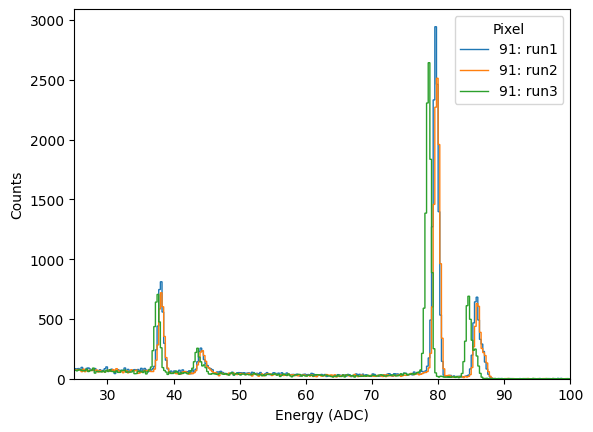

In [149]:
test_runs = [8626,8685,8837]
for i in range(len(test_runs)):
    plt.stairs(dd[test_runs[i]]['91'],b,label = '91: run%d'%(i+1))

# plt.stairs(UDETenergy[8718]['99'],bin_edges,label = '99')
plt.xlim(25,100)
# plt.ylim(0,1700)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

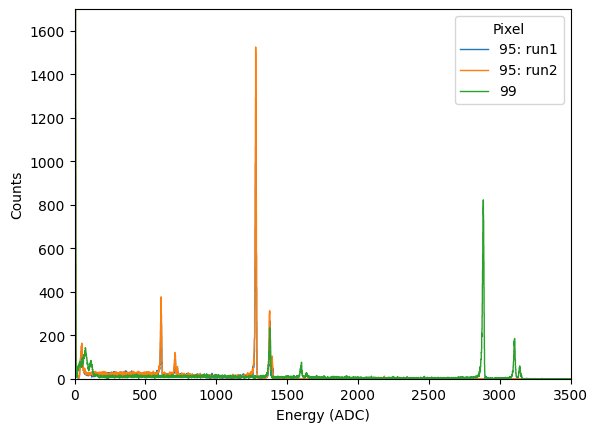

In [470]:
test_runs = [8718,8830]
for i in range(len(test_runs)):
    plt.stairs(UDETenergy[test_runs[i]]['95'],bin_edges,label = '95: run%d'%(i+1))

plt.stairs(UDETenergy[8718]['99'],bin_edges,label = '99')
plt.xlim(0,3500)
plt.ylim(0,1700)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

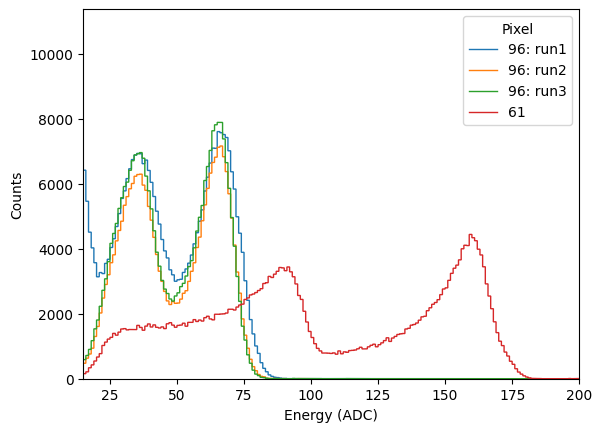

In [375]:
# test_runs = [8626,8635,8685,8692,8837,8862]
test_runs = [8652,8706,8850]
for i in range(len(test_runs)):
    plt.stairs(UDETenergy[test_runs[i]]['96'],bin_edges,label = '96: run%d'%(i+1))

plt.stairs(UDETenergy[8708]['61'],bin_edges,label = '61')
plt.xlim(15,200)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

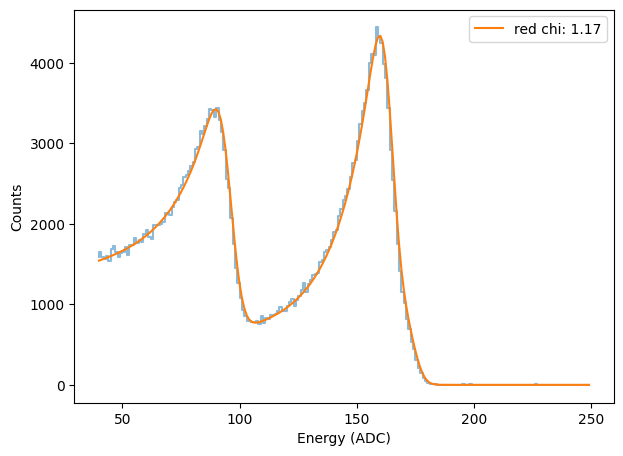

In [377]:
peak_finder_props = (10,None,5,35,3,None,0.5,None)
sigs0_df = {'sig1':5,'sig2':5}
r = modf.get_mod_expo_fit_long(8708,UDETenergy[8708],bin_edges,'61',40,250,2,peak_finder_props,sigs0_df,2,source='cd',plot=True)

In [378]:
r['cen1']['error'],r['cen2']['error']

(0.07421196301514112, 0.08725652979370112)

In [ ]:
df = {}
df[61] = {}
df[61]['peak1'] = 95.88
df[61]['peak2'] = 164.67

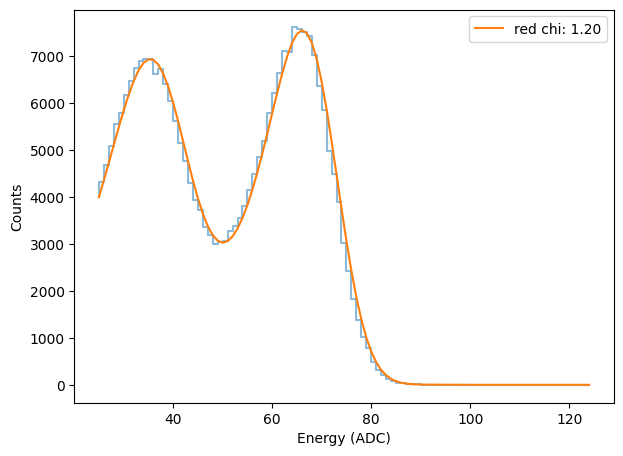

In [419]:
peak_finder_props = (10,None,5,35,3,None,0.5,None)
sigs0_df = {'sig1':5,'sig2':5}
r = modf.get_mod_expo_fit_long(8652,UDETenergy[8652],bin_edges,'96',25,125,2,peak_finder_props,sigs0_df,2,source='cd',plot=True)

[266]
{'amp1': 1976.0, 'cen1': 2966, 'sig1': 5}


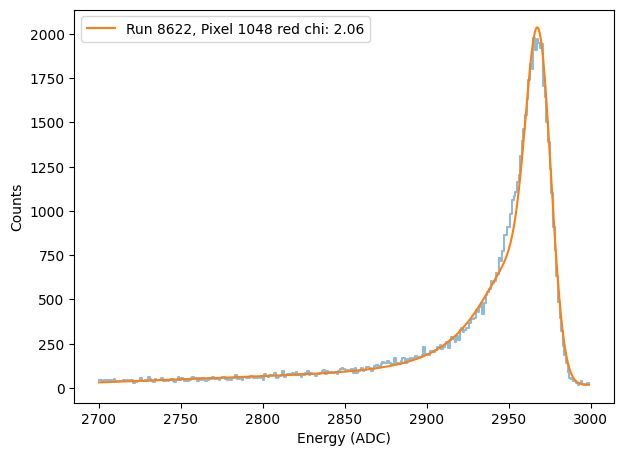

In [14]:
peak_finder_props = (10,None,20,35,10,None,0.5,None)
sigs2_df = {'sig1':5,'sig2':7,'sig3':7}
r = bi_fit.get_UDETbi_fit_long(8622,LDETenergy[8622],bin_edges,'1048',2700,3000,1,peak_finder_props,sigs2_df,plot=True)

In [15]:
r

{'time': {},
 'chi2': 601.8721334799104,
 'red chi2': 2.0612059365750355,
 'num_peaks': {'value': 1, 'error': 0},
 'sig_ratio': {'value': 0.04483177367911839, 'error': 0.0011083277439884655},
 'amp_ratio': {'value': 0.9999999999811932, 'error': 0.33213552785070155},
 'slope': {'value': 0.3441743193965281, 'error': 0.020480908147753482},
 'intercept': {'value': -1015.5069116562636, 'error': 61.344172265549645},
 'amp1': {'value': 1872.3965740745562, 'error': 20.126883061454656},
 'cen1': {'value': 2968.4299898279155, 'error': 0.12452029384654904},
 'sig1': {'value': 7.62185112530247, 'error': 0.08561160598771496},
 'step1_ratio': {'value': 0.0625115374876247, 'error': 0.0030962512989848407}}

In [401]:
df['91,1'] = {}
df['91,1']['peak1'] = 40.55
df['91,1']['peak2'] = 71.38

In [408]:
df['91,2'] = {}
df['91,2']['peak1'] = 39.14
df['91,2']['peak2'] = 69.03

In [409]:
pd.DataFrame(df)

,61,"91,1","91,2"
peak1,95.88,40.55,39.14
peak2,164.67,71.38,69.03


In [420]:
r['cen1']['value'],r['cen2']['value']

(40.545430412497836, 71.38427398376318)

In [421]:
r['cen1']['error'],r['cen2']['error']

(0.09390446837870371, 0.9723840249604319)

In [376]:
cd_keV = [62.5196,84.2278]

In [446]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(cd_keV),np.array([95.88204027418395, 164.66872276435868]),
                       np.array([0.07421196301514112, 0.08725652979370112]))

In [447]:
outr.params['m'].value,outr.params['b'].value

(3.1686958149535522, -102.22355459838613)

In [448]:
df = {}
df[61] = {}
df[61]['gain'] = outr.params['m'].value
df[61]['offset'] = outr.params['b'].value

In [449]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(cd_keV),np.array([40.545430412497836, 71.38427398376318]),
                       np.array([0.09390446837870371, 0.9723840249604319]))

In [450]:
outr.params['m'].value,outr.params['b'].value

(1.4206080454052081, -48.2704163430176)

In [451]:
df['91,1'] = {}
df['91,1']['gain'] = outr.params['m'].value
df['91,1']['offset'] = outr.params['b'].value

In [452]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(cd_keV),np.array([39.13917704820452, 69.02978015175694]),
                       np.array([0.2790599168579197, 0.6850428719093283]))

In [453]:
outr.params['m'].value,outr.params['b'].value

(1.376926834263201, -46.9457378591971)

In [454]:
df['91,2'] = {}
df['91,2']['gain'] = outr.params['m'].value
df['91,2']['offset'] = outr.params['b'].value

In [455]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(cd_keV),np.array([39.28205716915624, 67.91900883860937]),
                       np.array([0.4375611032211923, 0.19302181368529508]))

In [456]:
outr.params['m'].value,outr.params['b'].value

(1.3191767014056035, -43.19234253204152)

In [457]:
df['91,3'] = {}
df['91,3']['gain'] = outr.params['m'].value
df['91,3']['offset'] = outr.params['b'].value

In [458]:
pd.DataFrame(df)

,61,"91,1","91,2","91,3"
gain,3.168696,1.420608,1.376927,1.319177
offset,-102.223555,-48.270416,-46.945738,-43.192343


In [169]:
find_peaks.__defaults__ = (10,None,1,35,1,None,0.5,None)
peaks, props = find_peaks(dd[8837]['91'][280:360])
peaks, props

(array([34, 58]),
 {'peak_heights': array([2643.,  690.]),
  'prominences': array([2621.,  681.]),
  'left_bases': array([ 7, 52]),
  'right_bases': array([70, 70]),
  'widths': array([3.59610103, 3.72332852]),
  'width_heights': array([1332.5,  349.5]),
  'left_ips': array([31.93396226, 56.11952862]),
  'right_ips': array([35.53006329, 59.84285714])})

In [99]:
b[120:200][32]

38.0

In [324]:
len(peaks)

3

In [345]:
bin_edges[500:800][226]

726

In [206]:
UDETenergy[8626].keys()

dict_keys(['84', '72', '88', '87', '91', '110', '109'])

In [238]:
print('here',np.argmax(UDETenergy[8626]['91'][40:])+40)

here 79


In [208]:
not any(value=='91' for value in UDETenergy[8626].keys())

False

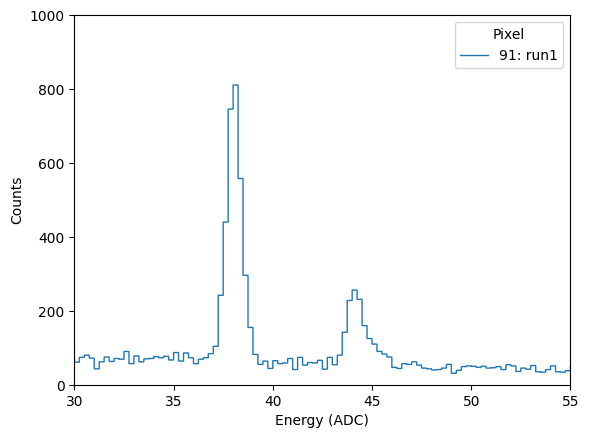

In [118]:
test_runs = [8626]
for i in range(len(test_runs)):
    plt.stairs(dd[test_runs[i]]['91'],b,label = '91: run%d'%(i+1))

# plt.stairs(UDETenergy[8718]['99'],bin_edges,label = '99')
plt.xlim(30,55)
plt.ylim(0,1000)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

In [191]:
reload(bi_fit)

<module 'DataAnalysis.bi_fit_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/bi_fit_functions.py'>

{'amp1': 705.0, 'cen1': 37.5, 'sig1': 1, 'amp2': 255.0, 'cen2': 43.5, 'sig2': 1, 'amp3': 127.5, 'cen3': 45.5, 'sig3': 1}


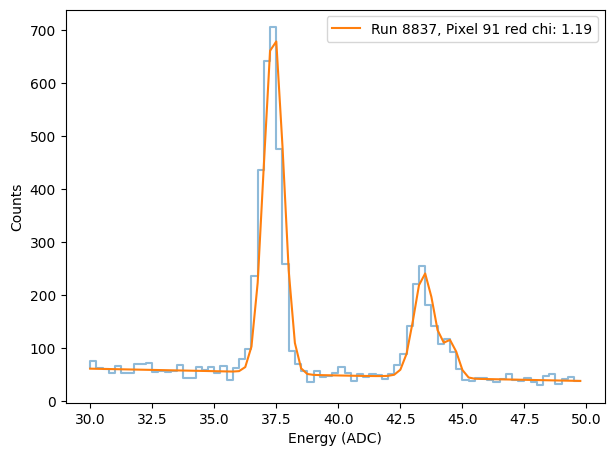

{'amp1': 2643.0, 'cen1': 78.5, 'sig1': 1, 'amp2': 690.0, 'cen2': 84.5, 'sig2': 1, 'amp3': 345.0, 'cen3': 86.5, 'sig3': 1}


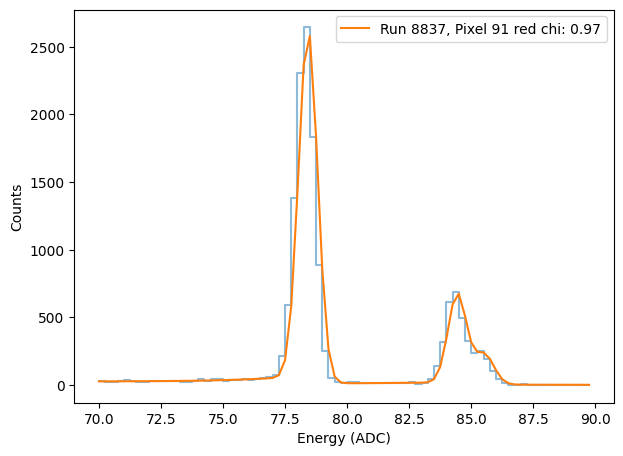

In [192]:
out = bi_fit.get_UDETbi_fit_results(dd, b, '91',[8837],low_region=40,plot=True,detector_type='UDET')

In [193]:
out

{8837: {1: {'time': {},
   'chi2': 76.17443142771975,
   'red chi2': 1.1902254910581211,
   'num_peaks': {'value': 3, 'error': 0},
   'sig_ratio': {'value': 6.65361432421463e-05, 'error': 218465.50162392794},
   'amp_ratio': {'value': 6.804703966967196e-09, 'error': 0.17741211262619233},
   'slope': {'value': -0.9425184556879174, 'error': 1.0853795437754987},
   'intercept': {'value': 84.28283733057371, 'error': 51.682580095239},
   'amp1': {'value': 651.5093826767135, 'error': 24.92107456941852},
   'cen1': {'value': 37.393152501114585, 'error': 0.01631650656419367},
   'sig1': {'value': 0.3918459701554211, 'error': 0.012147336786527364},
   'step1_ratio': {'value': 0.005247516411394079, 'error': 0.1639012059098464},
   'amp2': {'value': 183.95362722074407, 'error': 76.99440196388771},
   'cen2': {'value': 43.44571582642126, 'error': 0.07388564967149609},
   'sig2': {'value': 0.3937596421573819, 'error': 0.08562520750115649},
   'step2_ratio': {'value': -0.09999998392012388, 'error': 

In [430]:
run = 8692
out[run][1]['cen1']['value'],out[run][1]['cen2']['value'],out[run][1]['cen3']['value']

(394.45344230851487, 454.145431282999, 463.48085946421065)

In [431]:
out[run][1]['cen1']['error'],out[run][1]['cen2']['error'],out[run][1]['cen3']['error']

(0.11721125563806319, 2.1605693361162053, 9.378944815347396)

In [432]:
out[run][2]['cen1']['value'],out[run][2]['cen2']['value'],out[run][2]['cen3']['value']

(806.2097521639739, 866.1935269841032, 876.6634553119814)

In [433]:
out[run][2]['cen1']['error'],out[run][2]['cen2']['error'],out[run][2]['cen3']['error']

(0.05864987512013153, 0.6463592210583538, 1.8395835034220573)

In [132]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [198]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values)[2:],
                       np.array([37.393152501114585, 43.44571582642126, 44.55228283148546,
                                 78.42719313192205, 84.44396573044733, 85.5149949647676]),
                       np.array([0.01631650656419367, 0.07388564967149609, 0.09870964786086668,
                                 0.004144449773489388, 0.01639340338270251, 0.041927578637120426]))

In [155]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values)[2:],
                       np.array([38.03576754345108, 45.36682116221373, 44.211724596045165,
                                 79.68913542613686, 85.82518640644581, 86.93192978838218]),
                       np.array([0.013592824980360048, 0.18829008559545826, 0.06285469276548569,
                                 0.00417014956170372, 0.017771858289637555, 0.044630275627651435]))

In [134]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values)[2:],
                       np.array([37.922193712424736, 43.97736463756962, 44.9640853248136,
                                 79.52243969972456, 85.55114563447003, 86.31945249085713]),
                       np.array([0.016528640308164585, 0.07540445006290483, 0.37088413897018463,
                                 0.00552759583583381, 0.02641341619651935, 0.19843031823051305]))

In [199]:
outr.params

name,value,standard error,relative error,initial value,min,max,vary
m,0.08303455,2.4210e-05,(0.03%),3,-inf,inf,True
b,-0.22187099,0.02251524,(10.15%),0,-inf,inf,True


In [497]:
reload(bi_fit)

<module 'DataAnalysis.bi_fit_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/bi_fit_functions.py'>

{'amp1': 160.0, 'cen1': 81, 'sig1': 5, 'amp2': 85.0, 'cen2': 112, 'sig2': 5}


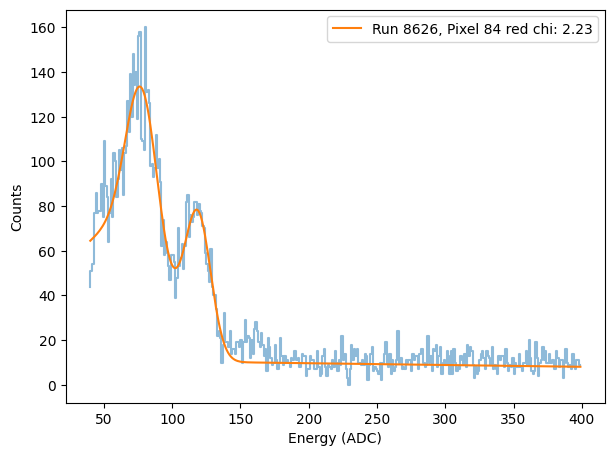

{'amp1': 227.0, 'cen1': 1411, 'sig1': 5, 'amp2': 75.0, 'cen2': 1636, 'sig2': 6, 'amp3': 37.5, 'cen3': 1638, 'sig3': 6}


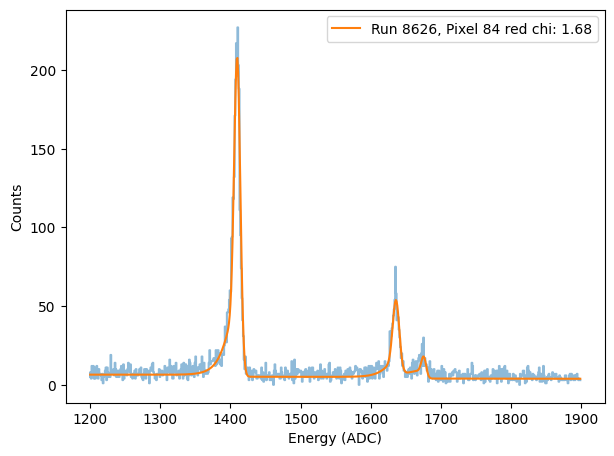

{'amp1': 518.0, 'cen1': 2951, 'sig1': 5, 'amp2': 130.0, 'cen2': 3175, 'sig2': 6, 'amp3': 65.0, 'cen3': 3177, 'sig3': 6}


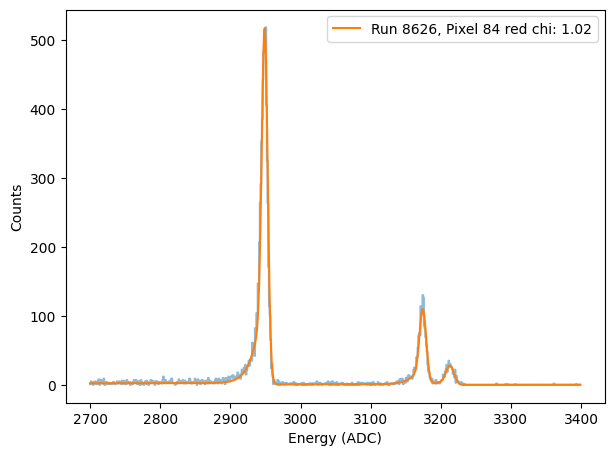

In [208]:
out = bi_fit.get_UDETbi_fit_results(UDETenergy, bin_edges, '84',[8626],low_region=40,plot=True,detector_type='UDET')

In [209]:
run = 8626
out[run][1]['cen1']['value'],out[run][1]['cen2']['value'],out[run][1]['cen3']['value']

(1409.8135812267574, 1636.2826263432314, 1675.7701405415714)

In [210]:
out[run][1]['cen1']['error'],out[run][1]['cen2']['error'],out[run][1]['cen3']['error']

(0.19741277912315375, 0.40504466174484316, 0.8662566963790133)

In [211]:
out[run][2]['cen1']['value'],out[run][2]['cen2']['value'],out[run][2]['cen3']['value']

(2948.9843776728353, 3174.581943631002, 3213.2916903193727)

In [212]:
out[run][2]['cen1']['error'],out[run][2]['cen2']['error'],out[run][2]['cen3']['error']

(0.08752722757311245, 0.17680329468625716, 0.3840618593650566)

In [213]:
out[run][0]['cen1']['value'],out[run][0]['cen2']['value']

(77.93979722108169, 118.836015444241)

In [214]:
out[run][0]['cen1']['error'],out[run][0]['cen2']['error']

(14.000241000526557, 7.336177023299134)

In [207]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [215]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values),
                       np.array([77.93979722108169, 118.836015444241,
                                 1409.8135812267574, 1636.2826263432314, 1675.7701405415714,
                                 2948.9843776728353, 3174.581943631002, 3213.2916903193727]),
                       np.array([14.000241000526557, 7.336177023299134,
                                 0.19741277912315375, 0.40504466174484316, 0.8662566963790133,
                                 0.08752722757311245, 0.17680329468625716, 0.3840618593650566]))

In [505]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values),
                       np.array([78.71877605977782, 115.25678943369422,
                                 1378.8300730667852, 1599.2795170252105, 1638.0306548668952,
                                 2884.143571010416, 3104.4639407506497, 3142.3559090388467]),
                       np.array([13.819303470854749, 15.202014906829298,
                                 0.22679145056709216, 0.40923210470175325, 0.866930567945315,
                                 0.0772833483548924, 0.13126691574478364, 0.2744361043237648]))

In [216]:
outr.params

name,value,standard error,relative error,initial value,min,max,vary
m,3.11458485,2.1193e-04,(0.01%),3,-inf,inf,True
b,-1.11433057,0.19130090,(17.17%),0,-inf,inf,True


In [483]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values)[2:],
                       np.array([610.5973074814095, 709.4748345198184, 725.8230431578722,
                                 1278.8415816288887, 1376.8822528965645, 1393.7763389385614]),
                       np.array([0.18593975743305943, 0.32494541020063034, 0.8617957434167772,
                                 0.06181365449863373, 0.15876793044506218, 0.42520702670938315]))

In [494]:
params = Parameters()
params.add('m', value=3)
params.add('b', value=0)
outb,outr = bf.get_fit(bf.linear_model,bf.linear_residual,params,np.array(simulated_keV_values)[2:],
                       np.array([610.4604571322338, 708.9679839762911, 725.8384905126634,
                                 1278.5247453199822, 1376.238325840146, 1393.68826326697]),
                       np.array([0.18512060059704655, 0.3298984410053877, 0.7012517557943019,
                                 0.05489426680274385, 0.12109356268146591, 0.3007204228385535]))

In [496]:
outr.params

name,value,standard error,relative error,initial value,min,max,vary
m,1.35167864,3.9570e-04,(0.03%),3,-inf,inf,True
b,-1.79222599,0.36753754,(20.51%),0,-inf,inf,True


In [27]:
LDETpixels = ['1009','1010','1011','1012','1013','1017','1018','1019','1020','1021','1022','1023','1026','1027','1028','1029','1030','1031','1032',
               '1033','1037','1038','1039','1040','1041','1042','1043','1044','1047','1048','1049','1050','1051','1052','1053','1054','1055','1056',
               '1060','1061','1062','1062','1063','1064','1065','1066','1067','1068','1069','1072','1073','1074','1075','1076','1077','1078','1079','1080',
               '1081','1084','1085','1086','1087','1088','1089','1090','1091','1092','1094','1095','1096','1098','1099','1100','1101','1102','1105',
               '1107','1108','1109','1111','1116','1117']

In [28]:
UDETpixels = ['9','11','12','17','19','20','21','26','27','28','29','30','31','32','37','38','39','40','41','42','43','47','48','49','50','51','52',
          '53','54','55','60','61','62','63','64','65','66','67','72','73','74','75','76','77','78','79','84','85','86','87','88','89','90','91',
          '94','95','96','97','98','99','100','101','102','105','106','107','108','109','110','115','117']

In [281]:
UDET_df['95'][8718]

{2: {'time': {},
  'chi2': 711.1484626796716,
  'red chi2': 1.4693150055365116,
  'num_peaks': {'value': 3, 'error': 0},
  'sig_ratio': {'value': 0.13341039923947373, 'error': 0.00789109377716737},
  'amp_ratio': {'value': 0.37530250050886754, 'error': 0.05094824607787761},
  'slope': {'value': 0.0021586919229062457, 'error': 0.0015297054343936555},
  'intercept': {'value': -3.121923940326572, 'error': 2.299319680503281},
  'amp1': {'value': 1172.0329882967278, 'error': 18.161808845576164},
  'cen1': {'value': 1278.8415816288887,
   'error': 0.06181365449863373,
   'keV value': 947.193705,
   'keV error': 0.002459},
  'sig1': {'value': 3.4730207750578943, 'error': 0.043852367147369335},
  'step1_ratio': {'value': 0.004919371267008393,
   'error': 0.00039554335485613145},
  'amp2': {'value': 260.7877392332169, 'error': 11.155543328154566},
  'cen2': {'value': 1376.8822528965645,
   'error': 0.15876793044506218,
   'keV value': 1019.613371,
   'keV error': 0.004933},
  'sig2': {'value': 

In [29]:
UDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, UDETpixels, run_numbers, plot=False,detector_type='UDET')

failed Bi fit for run: 8647, pixel: 17, region 1
failed Bi fit for run: 8828, pixel: 17, region 1
failed Bi fit for run: 8847, pixel: 17, region 1
failed Bi fit for run: 8859, pixel: 19, region 1
run: 8630, pixel: 27 too low amp, region 1
failed Bi fit for run: 8689, pixel: 27, region 1
failed Bi fit for run: 8840, pixel: 27, region 1
run: 8624, pixel: 29 too low amp, region 2
failed Bi fit for run: 8834, pixel: 29, region 1
failed Bi fit for run: 8690, pixel: 30, region 1
failed Bi fit for run: 8690, pixel: 30, region 2
failed Bi fit for run: 8715, pixel: 37, region 1
failed Bi fit for run: 8624, pixel: 43, region 1
run: 8624, pixel: 43 too low amp, region 2
run: 8630, pixel: 43 too low amp, region 1
run: 8630, pixel: 43 too low amp, region 2
failed Bi fit for run: 8630, pixel: 43, region 3
run: 8637, pixel: 43 too low amp, region 1
failed Bi fit for run: 8637, pixel: 43, region 2
run: 8683, pixel: 43 too low amp, region 1
run: 8683, pixel: 43 too low amp, region 2
run: 8694, pixel: 4

In [226]:
LDETenergy[8626].keys()

dict_keys(['1037', '1026', '1048', '1040', '1030', '1041', '1044', '1033', '1043', '1055', '1010', '1013'])

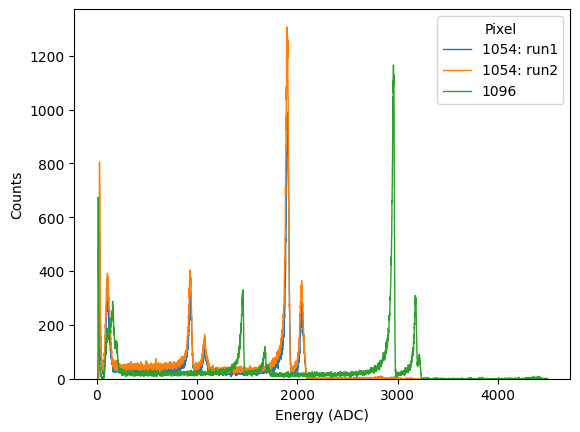

In [604]:
# test_runs = [8651,8705,8849]
test_runs = [8828, 8847]
             #8636,8652,8692,8693,8706,8718,8719,8829,8830,8850,8861,8862]
for i in range(len(test_runs)):
    plt.stairs(LDETenergy[test_runs[i]]['1054'],bin_edges,label = '1054: run%d'%(i+1))

plt.stairs(LDETenergy[8828]['1096'],bin_edges,label = '1096')
# plt.xlim(1550,2300)
# plt.ylim(0,1900)
plt.xlabel('Energy (ADC)')
plt.ylabel('Counts')
plt.legend(title='Pixel')
plt.show()

In [613]:
reload(bi_fit)

<module 'DataAnalysis.bi_fit_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/bi_fit_functions.py'>

[56]
{'amp1': 288.0, 'cen1': 156, 'sig1': 7, 'amp2': 144.0, 'cen2': 171, 'sig2': 7}


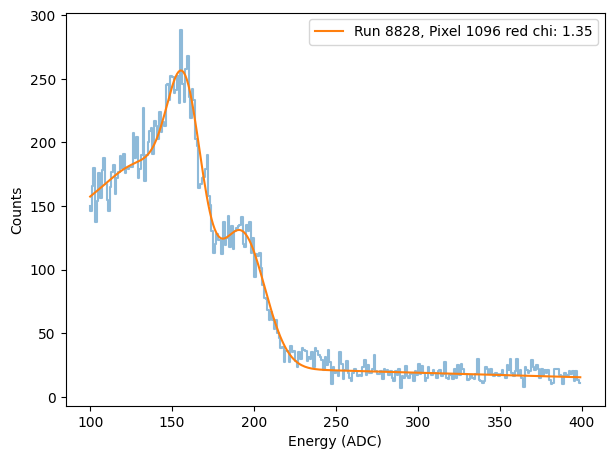

[257 477]
{'amp1': 331.0, 'cen1': 1457, 'sig1': 5, 'amp2': 119.0, 'cen2': 1677, 'sig2': 6, 'amp3': 59.5, 'cen3': 1692, 'sig3': 6}


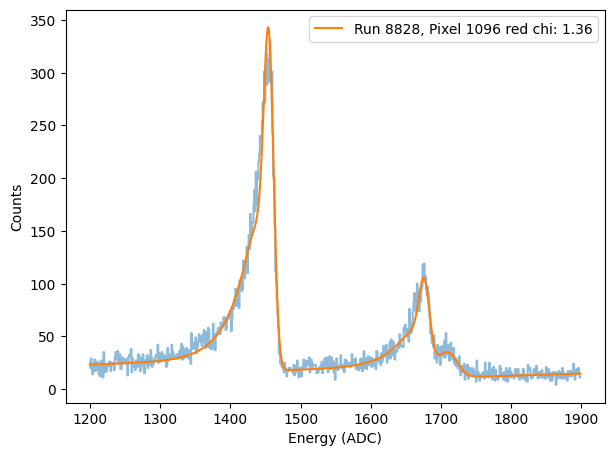

[258 476]
{'amp1': 1166.0, 'cen1': 2958, 'sig1': 5, 'amp2': 310.0, 'cen2': 3176, 'sig2': 7, 'amp3': 155.0, 'cen3': 3191, 'sig3': 7}


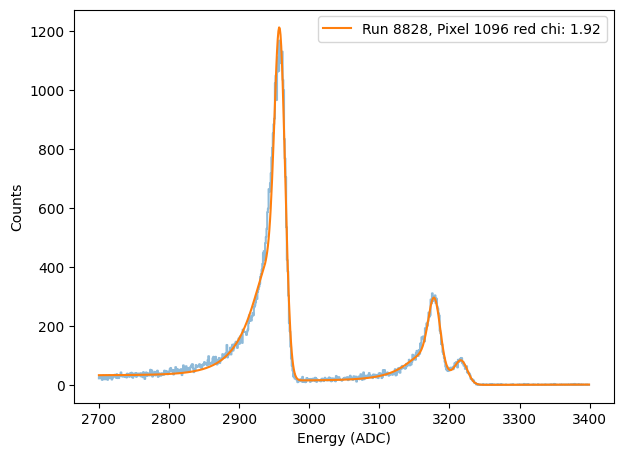

In [614]:
out = bi_fit.get_UDETbi_fit_results(LDETenergy, bin_edges, '1096',[8828],low_region=40,plot=True,detector_type='LDET')

In [615]:
out

{8828: {0: {'time': {},
   'chi2': 387.4475179708798,
   'red chi2': 1.3453038818433327,
   'num_peaks': {'value': 2, 'error': 0},
   'sig_ratio': {'value': 0.0250283956981856, 'error': 0.031177368981509596},
   'amp_ratio': {'value': 0.9999999779613054, 'error': 0.32042415809167607},
   'slope': {'value': -0.03606812744751991, 'error': 0.00817143209255716},
   'intercept': {'value': 29.72264986234746, 'error': 2.6445923842217547},
   'amp1': {'value': 167.72870643531905, 'error': 108.3051226647818},
   'cen1': {'value': 158.0669537571582, 'error': 2.4151521311848594},
   'sig1': {'value': 10.587577229370508, 'error': 2.2441953608205076},
   'step1_ratio': {'value': 0.558804827602732, 'error': 1.2066641280044035},
   'amp2': {'value': 102.73874546899765, 'error': 57.99501066617913},
   'cen2': {'value': 193.00006327822314, 'error': 7.05901657057565},
   'sig2': {'value': 13.775282556374156, 'error': 2.70601086579318},
   'step2_ratio': {'value': -0.09990175994108828,
    'error': 2.171

In [616]:
outr = get_low_gain_cal_all(out,8828)

In [617]:
outr.params

name,value,standard error,relative error,initial value,min,max,vary
m,3.04193287,4.9548e-04,(0.02%),3,-inf,inf,True
b,76.8267046,0.42959316,(0.56%),0,-inf,inf,True


In [414]:
# out = bi_fit.get_UDETbi_fit_results(LDETenergy, bin_edges, '1017',[8829],low_region=40,plot=True,detector_type='LDET')

In [415]:
# out

In [30]:
LDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, LDETenergy, bin_edges, LDETpixels, run_numbers, plot=False,detector_type='LDET')


run: 8720, pixel: 1011 too low amp, sig1 or sig2 region 1
failed Bi fit for run: 8720, pixel: 1011, region 3
failed Bi fit for run: 8826, pixel: 1011, region 3
failed Bi fit for run: 8857, pixel: 1011, region 3
LDET average too low, run 8644, pixel 1012
failed Bi fit for run: 8644, pixel: 1012, region 2
LDET average too low, run 8697, pixel 1012
run: 8697, pixel: 1012 too low amp, region 2
failed Bi fit for run: 8719, pixel: 1012, region 1
failed Bi fit for run: 8829, pixel: 1012, region 1
LDET average too low, run 8863, pixel 1012
failed Bi fit for run: 8863, pixel: 1012, region 2
LDET average too low, run 8626, pixel 1013
failed Bi fit for run: 8626, pixel: 1013, region 2
failed Bi fit for run: 8626, pixel: 1013, region 3
LDET average too low, run 8644, pixel 1013
LDET average too low, run 8651, pixel 1013
LDET average too low, run 8685, pixel 1013
failed Bi fit for run: 8685, pixel: 1013, region 2
LDET average too low, run 8697, pixel 1013
LDET average too low, run 8705, pixel 1013


In [31]:
# test_runs = [8622,8623,8624,8637,8649,8654,8684,8685,8689,8690,8706,8716,8830,8835,8837,8845,8850,8860]
# test_pixels = ['20','27','30','32','43','64','66','72','87','89','95','109','110']
# test_runs = [8624,8628,8643,8644,8693,8696,8712,8718,8719,8720,8829,8837,8838]
# test_pixels = ['1012','1020','1026','1030','1033','1042','1043','1044','1065','1069']
test_runs = [8636,8653,8693,8707,8853,8861]
test_pixels = ['1076']

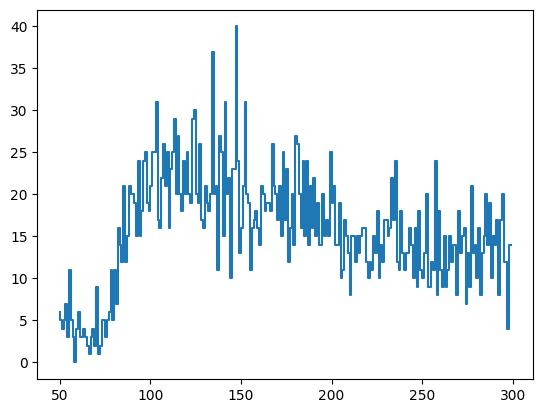

In [1497]:
plt.step(bin_edges[50:300],LDETenergy[8840]['1086'][50:300])

In [1539]:
reload(bi_fit)

<module 'DataAnalysis.bi_fit_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/bi_fit_functions.py'>

In [17]:
# LDET_test_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, LDETenergy, bin_edges, test_pixels, test_runs, plot=True,detector_type='LDET')

In [32]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

LDETsimulated_keV_values = np.array([22.269661+30,35.276915+30,450.020179+30,522.714534+30,535.039+30,
                                     944.193705+30,1016.613371+30,1029.008589+30])
LDETsimulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [33]:
calibration_peak_data,calibration_width_data,calibration_amp_data = bf.get_cal_peaks_df(UDET_df,simulated_keV_values,simulated_keV_errors)

In [34]:
LDETcalibration_peak_data,LDETcalibration_width_data,LDETcalibration_amp_data = bf.get_cal_peaks_df(LDET_df,LDETsimulated_keV_values,LDETsimulated_keV_errors)


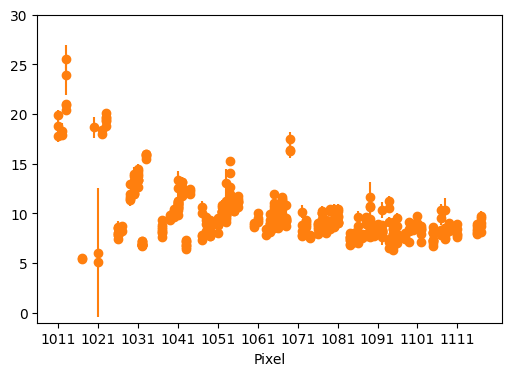

In [170]:
plotf.plot_peak_fit_params(LDETcalibration_width_data,peak='peak3',bottom_ylim=-1,top_ylim=30)

In [36]:
pixels = list(LDETcalibration_amp_data.keys())
for pixel in pixels:
    runs = list(LDETcalibration_amp_data[pixel].keys())
    for run in runs:
        try:
            amp = LDETcalibration_amp_data[pixel][run]['peak4']['value']
            error = LDETcalibration_amp_data[pixel][run]['peak4']['error']
            if amp<1:
                print(pixel,run,amp,error)
        except Exception as e:
            continue

1021 8829 1.7848680837762032e-06 1.7388259794761258


In [37]:
pixels = list(calibration_amp_data.keys())
for pixel in pixels:
    runs = list(calibration_amp_data[pixel].keys())
    for run in runs:
        try:
            amp = calibration_amp_data[pixel][run]['peak3']['value']
            error = calibration_amp_data[pixel][run]['peak3']['error']
            if amp<50:
                print(pixel,run,amp,error)
        except Exception as e:
            continue

27 8630 25.195325433268458 2.8870601180860294
27 8689 20.16406327607819 2.7553900750119285
27 8840 26.215250694761107 2.679914404456502
32 8654 28.559497359614703 2.436890575712369
32 8708 30.35968449747513 2.315247909990773
32 8854 35.382960261152455 6.9852537267654045
52 8709 38.55823589020378 2.6544165315322084
52 8855 42.78171445645725 4.121369505707245
64 8681 43.290597271643044 3.3983406924306316
87 8626 24.24988269925393 2.3384229014728377
87 8685 38.42401784275149 3.243877862592101
89 8682 23.912293490278397 1.9981224339708248
100 8652 33.7856681873026 3.141050947045069
100 8850 29.872990896889075 2.715439049203202
109 8651 31.037563377939776 2.6656658215987483
109 8652 19.65501556910509 1.8493353943048159
109 8705 29.56544381544192 3.0354392062414175
110 8649 40.45632487668338 4.472910092887661
110 8716 27.771351887385837 2.071449073886249
110 8845 35.169549800481576 2.7331821666046148


In [20]:
reload(plotf)

<module 'DataAnalysis.plot_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/plot_functions.py'>

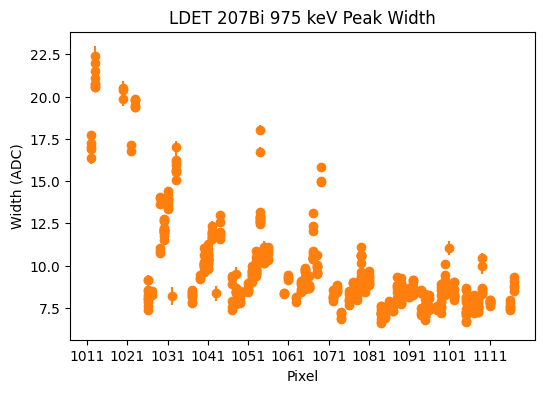

In [38]:
plotf.plot_peak_fit_params(LDETcalibration_width_data,peak='peak6',bottom_ylim=None,top_ylim=None,
                           title='LDET 207Bi 975 keV Peak Width',ylabel='Width (ADC)')

In [146]:
all_pix_nums = np.arange(1,128)
nabPy_sigmas = {}
for i in range(len(all_pix_nums)):
    p = str(all_pix_nums[i])
    if any(value==p for value in list(calibration_width_data.keys())):
        runs = list(calibration_width_data[p].keys())
        nabPy_sigmas[p] = calibration_width_data[p][runs[0]]['peak6']['value']
    else:
        nabPy_sigmas[p] = 0

In [157]:
all_pix_nums = np.arange(1001,1128)
LDETnabPy_sigmas = {}
for i in range(len(all_pix_nums)):
    p = str(all_pix_nums[i])
    if any(value==p for value in list(LDETcalibration_width_data.keys())):
        runs = list(LDETcalibration_width_data[p].keys())
        try:
            LDETnabPy_sigmas[p] = LDETcalibration_width_data[p][runs[0]]['peak6']['value']
        except Exception as e:
            LDETnabPy_sigmas[p] = 0
            continue
    else:
        LDETnabPy_sigmas[p] = 0

In [153]:
LDETcalibration_width_data['1011']

{8720: {'peak3': {'value': 18.789914947720955, 'error': 0.6093668647498033},
  'peak4': {'value': 21.550897977723334, 'error': 6.594679752314945},
  'peak5': {'value': 11.055693134261142, 'error': 3.475502782863854}},
 8826: {'peak1': {'value': 7.812147152983297, 'error': 5.473589425160981},
  'peak2': {'value': 17.031310608700213, 'error': 17.362057101769537},
  'peak3': {'value': 19.872149079903213, 'error': 0.5248184884728249},
  'peak4': {'value': 33.56787050922178, 'error': 2.3718332824988853},
  'peak5': {'value': 9.698918378255765, 'error': 3.4520432491298085}},
 8857: {'peak1': {'value': 8.27347070764152, 'error': 10.525596081658072},
  'peak2': {'value': 18.296698808696235, 'error': 17.081906079266574},
  'peak3': {'value': 17.756166221819992, 'error': 0.5406993374269219},
  'peak4': {'value': 19.59117622884969, 'error': 2.9840942512066033},
  'peak5': {'value': 22.539665859944968, 'error': 9.683810469187744}}}

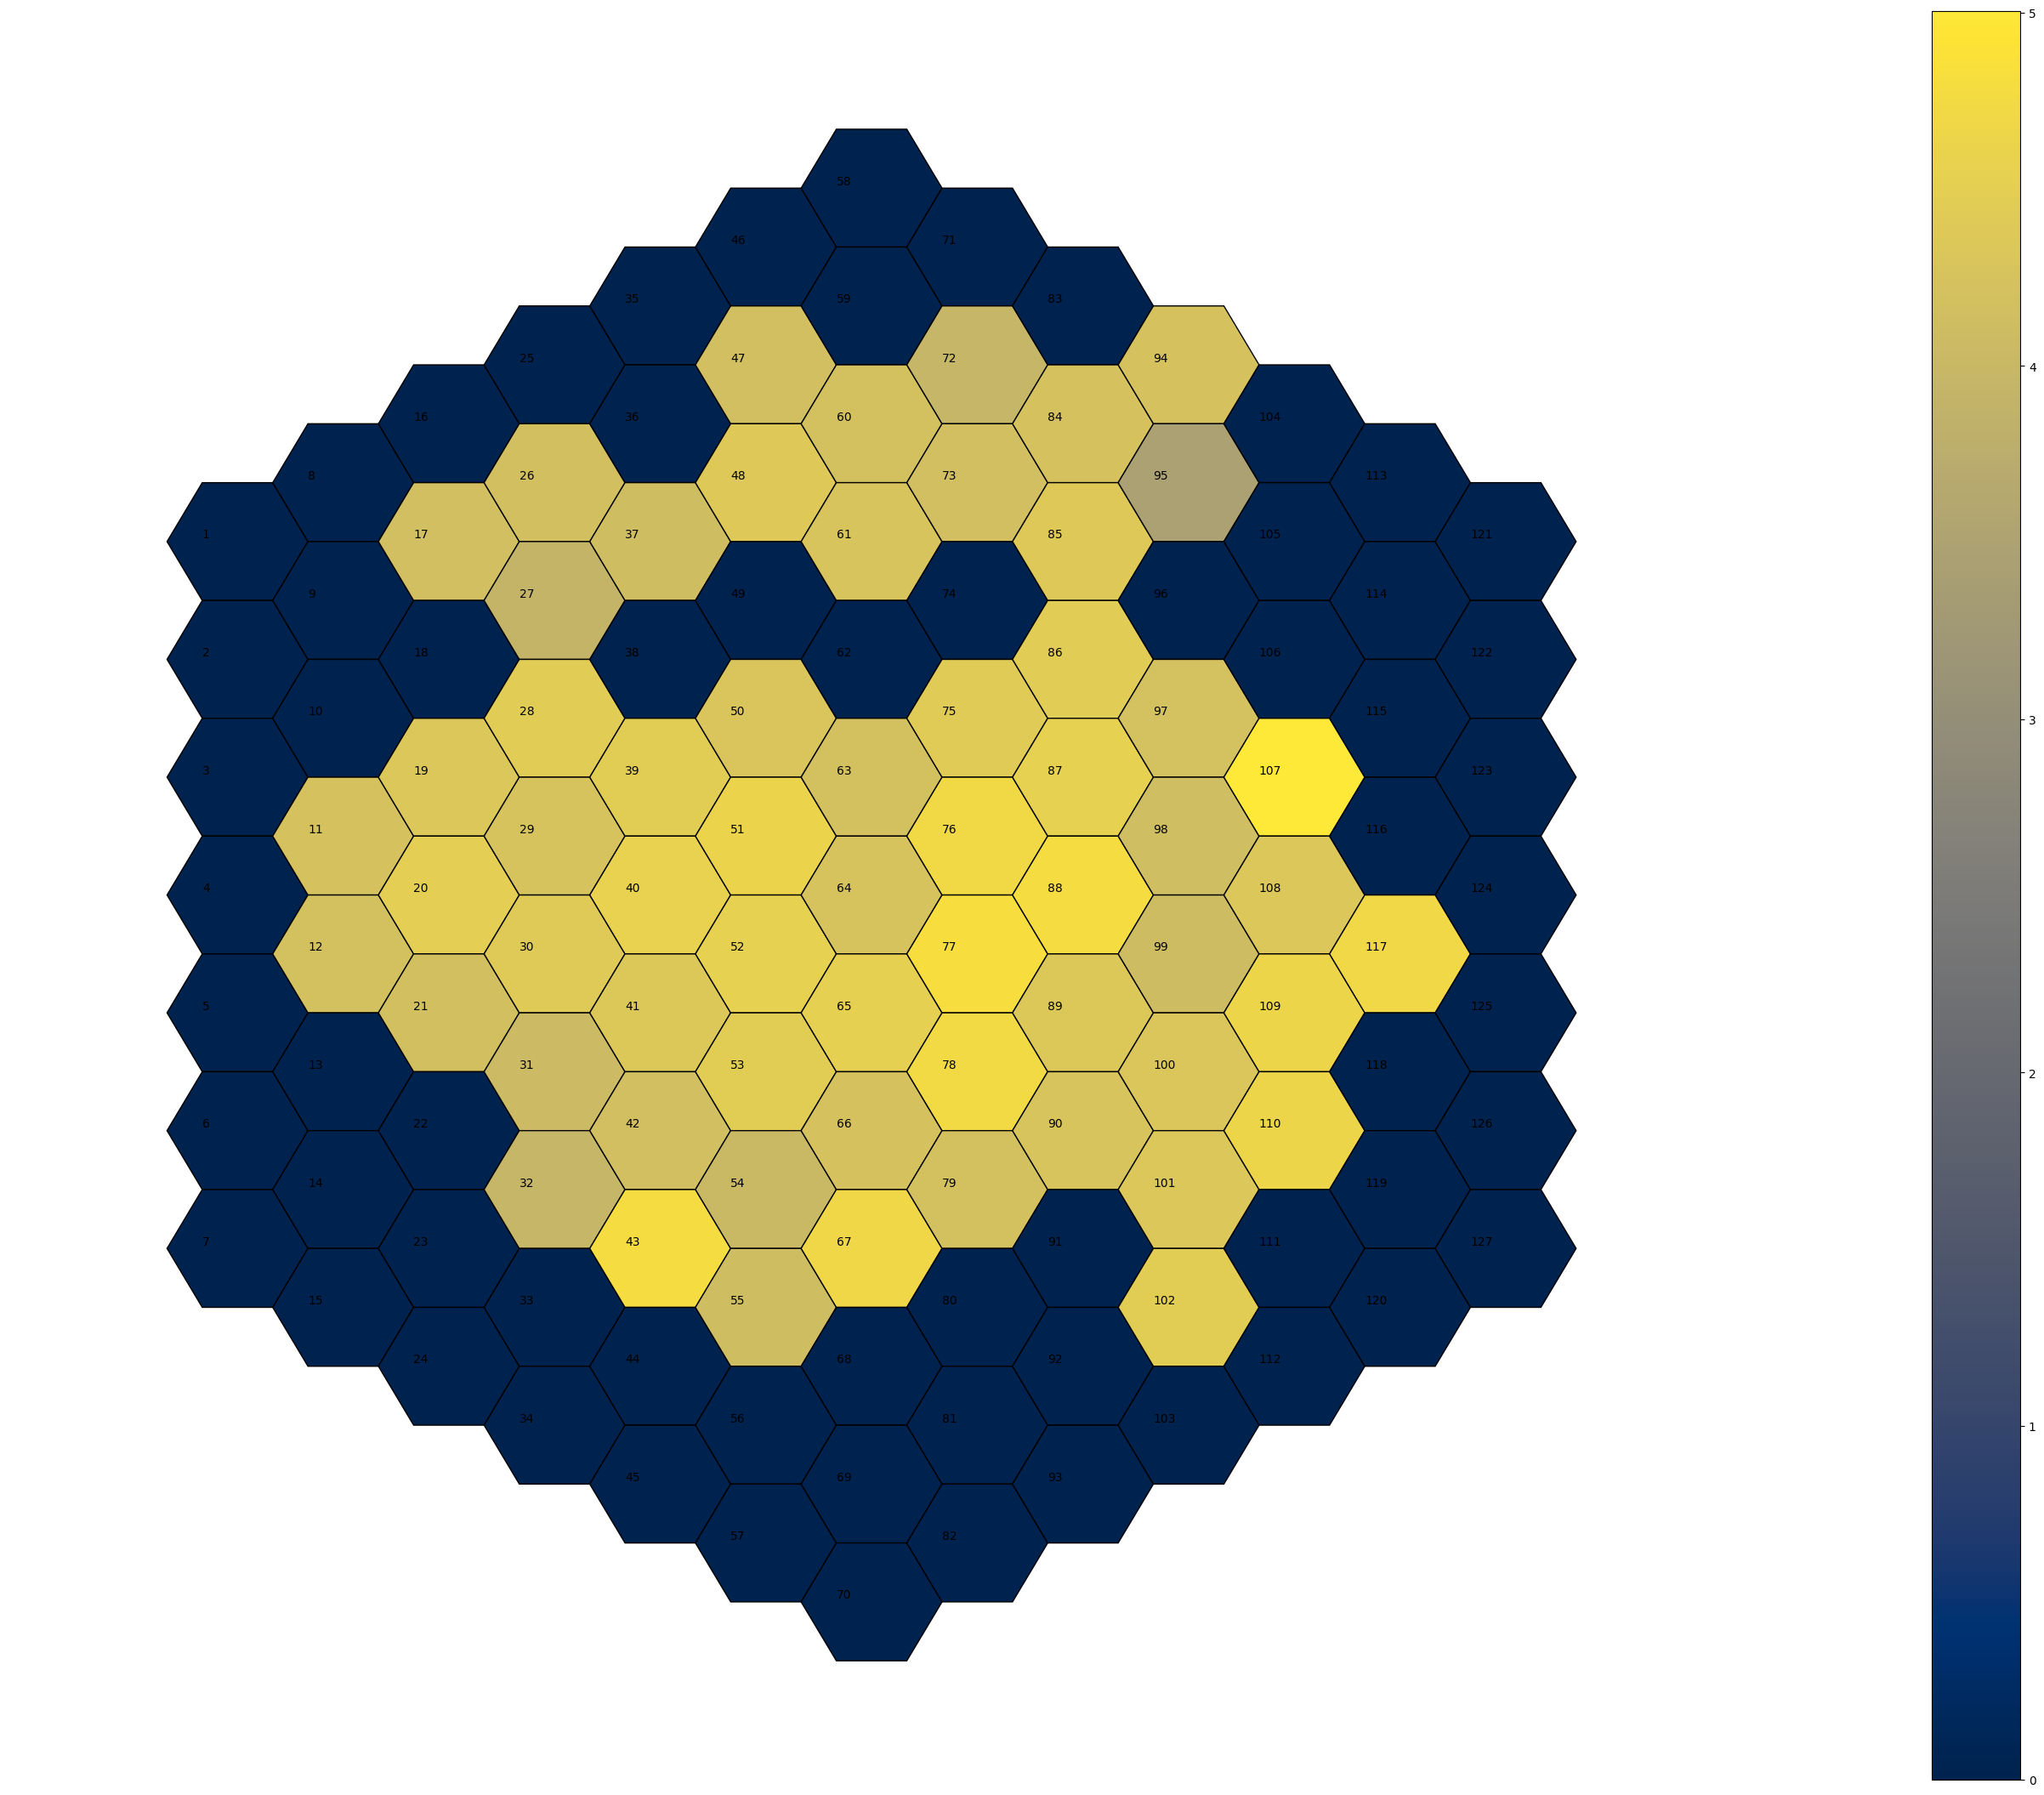

In [148]:
Nab.nplt.plotOneDetector(list(nabPy_sigmas.values()),size = 3)

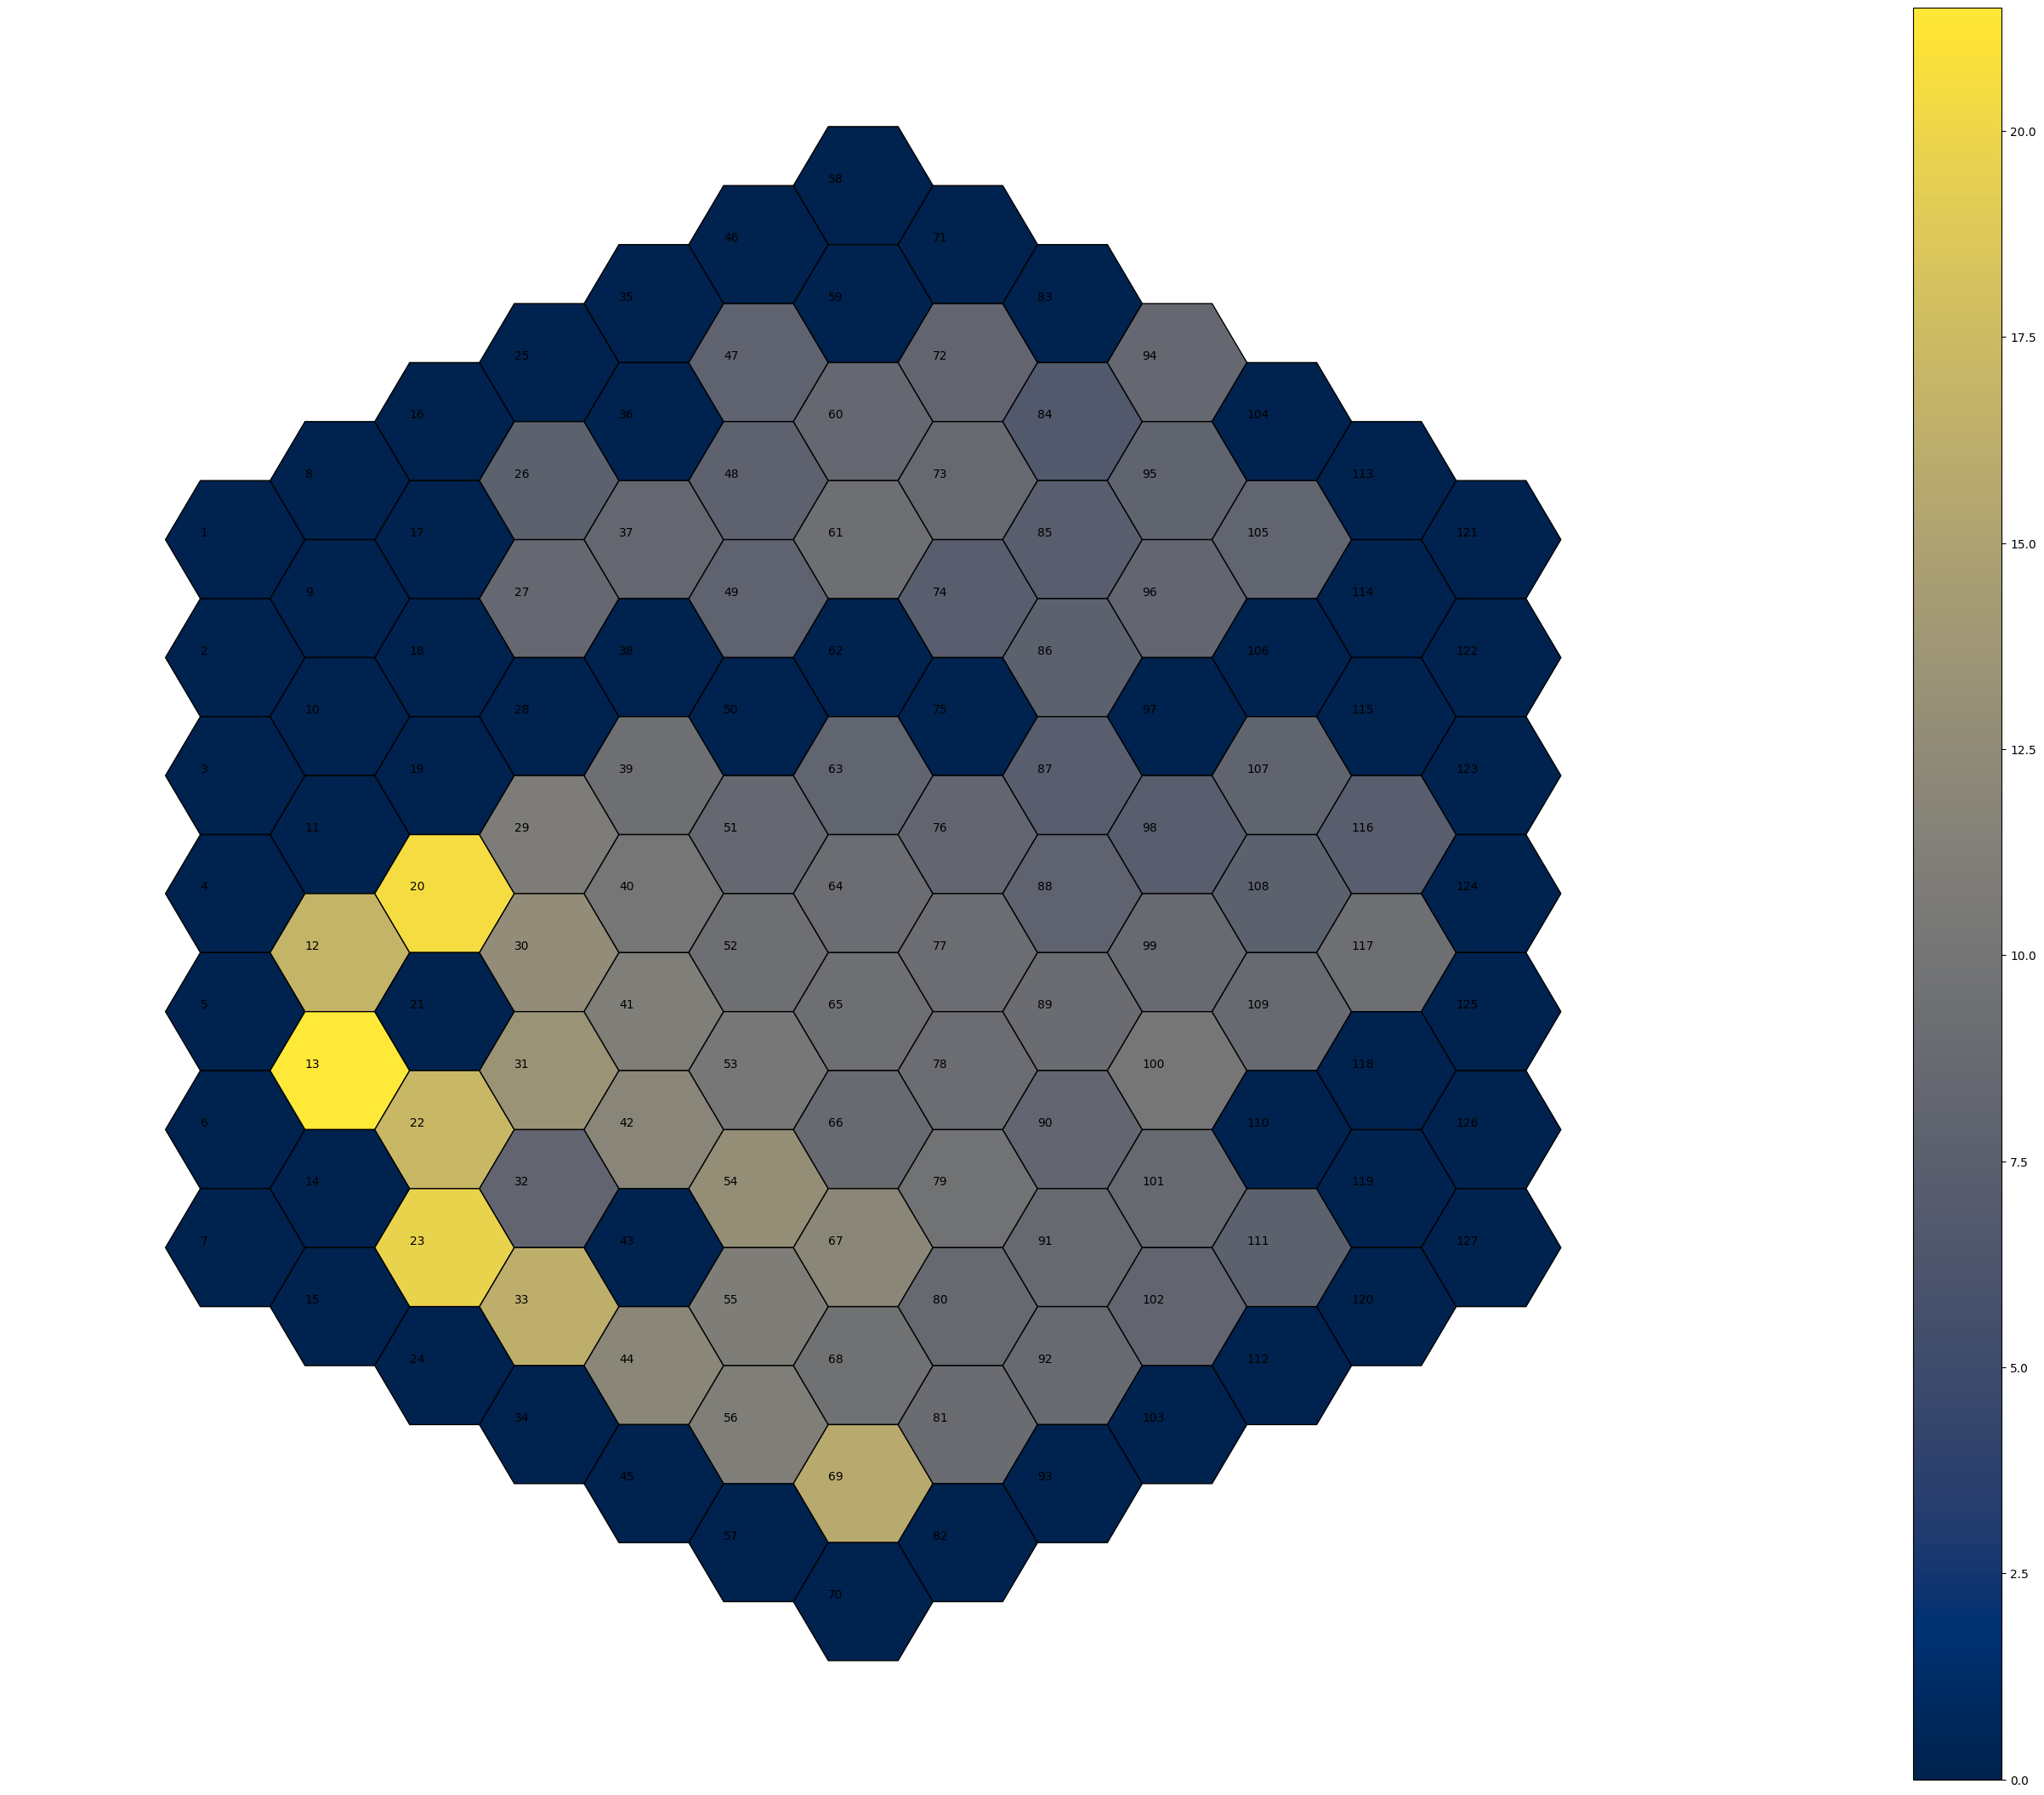

In [158]:
Nab.nplt.plotOneDetector(list(LDETnabPy_sigmas.values()),size = 3)

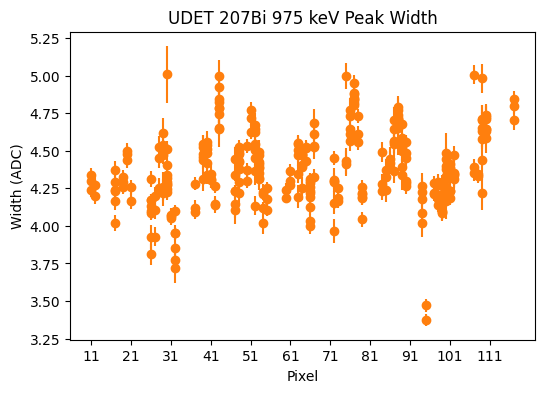

In [39]:
plotf.plot_peak_fit_params(calibration_width_data,peak='peak6',bottom_ylim=None,top_ylim=None,
                           title='UDET 207Bi 975 keV Peak Width',ylabel='Width (ADC)')

In [40]:
calibration_linear_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='linear')
calibration_quadratic_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='quadratic')

In [41]:
reload(bf)

<module 'DataAnalysis.basic_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/basic_functions.py'>

In [42]:
LDETcalibration_linear_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='linear',detector='LDET')
LDETcalibration_quadratic_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='quadratic',detector='LDET')

In [43]:
cal_df = bf.get_calibration_fit_df_for_db(calibration_linear_results,quad=False)

In [44]:
cal_df_q = bf.get_calibration_fit_df_for_db(calibration_quadratic_results,quad=True)

In [45]:
cal_r = pd.DataFrame(cal_df)
cal_r2 = pd.DataFrame(cal_df_q)
df_combined = pd.concat([cal_r, cal_r2], ignore_index=True)

In [46]:
calibration_quadratic_results['117'][8849].params['q'].stderr

3.5301673649997973e-06

In [47]:
df_combined

,pixel_number,run_number,calibration_type,gain,gain_uncertainty,offset,offset_uncertainty,quadratic,quadratic_uncertainty,chi2,reduced_chi2,gain_offset_correlation,gain_quadratic_correlation,offset_quadratic_correlation
0,11,8655,linear,2.975789,0.000273,-1.204230,0.254968,NaN,NaN,2.700427,0.450071,-0.985418,NaN,NaN
1,11,8709,linear,2.975227,0.000539,-1.055029,0.497010,NaN,NaN,15.538616,2.589769,-0.980149,NaN,NaN
2,11,8855,linear,2.974755,0.000271,-1.292408,0.251993,NaN,NaN,2.777642,0.462940,-0.985521,NaN,NaN
3,12,8646,linear,3.047962,0.000420,-1.202184,0.389662,NaN,NaN,6.179405,1.029901,-0.984324,NaN,NaN
4,12,8848,linear,3.047070,0.000426,-1.290857,0.390651,NaN,NaN,7.368576,1.228096,-0.981451,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,110,8687,quadratic,3.067402,0.006490,-2.532244,2.155900,-4.458531e-06,0.000004,6.454977,1.290995,-0.989119,-0.996806,0.974653
516,110,8842,quadratic,3.075803,0.007570,-6.216003,2.475807,-9.020369e-06,0.000005,8.274134,1.654827,-0.992854,-0.997852,0.983320
517,117,8651,quadratic,3.071830,0.006004,-1.177689,1.977974,3.335829e-07,0.000004,10.338392,2.067678,-0.978512,-0.993928,0.950896
518,117,8705,quadratic,3.073428,0.006475,-2.020630,2.248515,-9.870738e-07,0.000004,13.461885,2.692377,-0.963799,-0.989105,0.914693


In [48]:
cal_r

,pixel_number,run_number,calibration_type,gain,gain_uncertainty,offset,offset_uncertainty,quadratic,quadratic_uncertainty,chi2,reduced_chi2,gain_offset_correlation,gain_quadratic_correlation,offset_quadratic_correlation
0,11,8655,linear,2.975789,0.000273,-1.204230,0.254968,None,None,2.700427,0.450071,-0.985418,None,None
1,11,8709,linear,2.975227,0.000539,-1.055029,0.497010,None,None,15.538616,2.589769,-0.980149,None,None
2,11,8855,linear,2.974755,0.000271,-1.292408,0.251993,None,None,2.777642,0.462940,-0.985521,None,None
3,12,8646,linear,3.047962,0.000420,-1.202184,0.389662,None,None,6.179405,1.029901,-0.984324,None,None
4,12,8848,linear,3.047070,0.000426,-1.290857,0.390651,None,None,7.368576,1.228096,-0.981451,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,110,8687,linear,3.060866,0.000519,-0.409326,0.483152,None,None,7.772729,1.295455,-0.983835,None,None
256,110,8842,linear,3.062642,0.000574,-1.974415,0.521119,None,None,13.297395,2.216233,-0.977328,None,None
257,117,8651,linear,3.072313,0.000603,-1.329869,0.559229,None,None,10.351928,1.725321,-0.980435,None,None
258,117,8705,linear,3.071994,0.000874,-1.559910,0.833710,None,None,13.596988,2.266165,-0.992864,None,None


In [51]:
# pixels = list(gain.keys())
# for i in range(len(pixels)):
#     pixel = int(pixels[i])
#     try:
#         truth_arr = cal_r.loc[cal_r['pixel_number']==pixel,'run_number'].values == test_db.loc[test_db['pixel_number']==pixel,'run_number'].values
#     except Exception as e:
#         print(pixel)
#     if np.all(truth_arr):
#         pass
#     else:
#         print(pixel)

In [1607]:
cal_r.loc[cal_r['pixel_number']==12,'run_number'].values == test_db.loc[test_db['pixel_number']==12,'run_number'].values

array([ True,  True])

In [1654]:
test_db.loc[test_db['pixel_number']==109,'run_number'].values

array([8622, 8651, 8681, 8705, 8849])

In [1655]:
cal_r.loc[cal_r['pixel_number']==109,'run_number'].values

array([8622, 8681])

In [1583]:
len(cal_r)

260

In [1589]:
with open('DatabaseFiles/RunPixels/run_pixel_db.csv') as f:
    csv.DictReader(f)
    test_db = pd.read_csv(f)

In [1590]:
test_db

,pixel_number,run_number,detector,source
0,11,8655,UDET: Goop!,Bi-207-9177 Y2-744
1,11,8709,UDET: Goop!,Bi-207-9177 Y2-744
2,11,8855,UDET: Goop!,Bi-207-9177 Y2-744
3,12,8646,UDET: Goop!,Bi-207-9177 Y2-744
4,12,8848,UDET: Goop!,Bi-207-9177 Y2-744
...,...,...,...,...
247,110,8687,UDET: Goop!,Bi-207-8890 X5-302
248,110,8842,UDET: Goop!,Bi-207-8890 X5-302
249,117,8651,UDET: Goop!,Bi-207-8890 X5-302
250,117,8705,UDET: Goop!,Bi-207-8890 X5-302


In [1278]:
keys = list(calibration_linear_results.keys())
runs_calibrated = []
for i in keys:
    runs = list(calibration_linear_results[i].keys())
    for j in range(len(runs)):
        if any(value==str(runs[j]) for value in runs_calibrated):
            pass
        else:
            runs_calibrated.append(str(runs[j]))

In [1279]:
len(runs_calibrated)

104

In [729]:
runs_calibrated
with open('DatabaseFiles/Runs/calibrated_runs.txt', 'w') as file:
    file.write('\n'.join(runs_calibrated))

In [58]:
with open('DatabaseFiles/Runs/run_db.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [59]:
metadata

,run_number,UDET_bias,LDET_bias,HV,MAIN,UDET,date,start_time,end_time,ExB,UDET_armor,UDET_ring,LDET_armor,UDET_leakage,LDET_leakage
0,8655,300.0,300.0,27.0,137.0,137.0,2025-10-14,20:51:38,20:51:36,-1499.050847,134.458618,119.984912,129.964194,0.007057,35.94986
1,8709,300.0,300.0,27.0,137.0,137.0,2025-10-21,19:48:30,19:48:28,-1499.000000,134.458499,119.991606,129.974482,0.007585,35.96716
2,8855,300.0,300.0,27.0,137.0,137.0,2025-10-31,15:31:48,15:31:46,-1499.117949,134.275259,120.013290,130.077537,0.007338,35.86735
3,8646,300.0,300.0,27.0,137.0,137.0,2025-10-14,15:35:23,15:35:21,-1499.078125,134.468330,119.999757,129.926447,0.007080,35.94495
4,8848,300.0,300.0,27.0,137.0,137.0,2025-10-30,20:20:45,20:20:43,-1499.000000,134.306473,120.004832,130.048831,0.007573,35.63690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,8720,300.0,300.0,27.0,137.0,137.0,2025-10-22,16:18:29,16:50:08,-1499.028090,134.445196,120.003004,130.028883,0.007329,36.64413
100,8826,300.0,300.0,27.0,137.0,137.0,2025-10-29,19:53:08,20:23:09,-1499.386364,134.329690,119.994170,130.084202,0.008578,36.42743
101,8857,300.0,300.0,27.0,137.0,137.0,2025-10-31,16:42:53,17:17:46,-1499.062802,134.281502,120.014718,130.094448,0.007322,36.35307
102,8719,300.0,300.0,27.0,137.0,137.0,2025-10-22,15:45:26,16:15:26,-1499.269962,134.445041,120.003693,130.040813,0.007344,36.53752


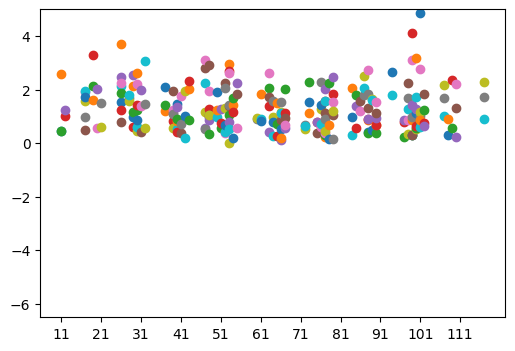

In [736]:
plotf.plot_goodness_of_fit(calibration_linear_results,chi2=False,reduced_chi2=True,bottom_ylim=None,top_ylim=5)

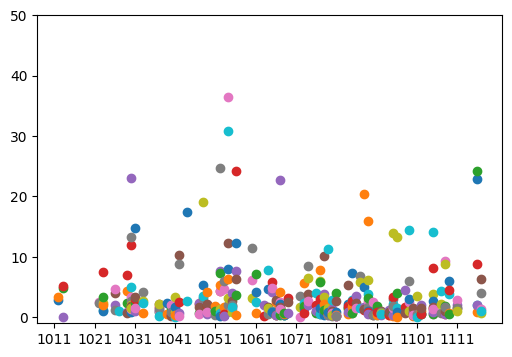

In [766]:
plotf.plot_goodness_of_fit(LDETcalibration_linear_results,chi2=False,reduced_chi2=True,bottom_ylim=-1,top_ylim=50)

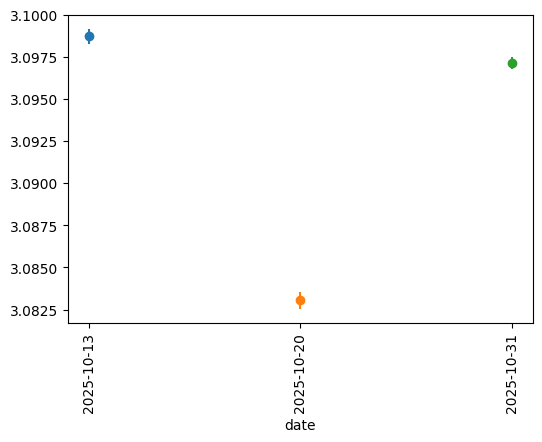

In [86]:
plotf.plot_calibration_results('75',calibration_linear_results,metadata,gain=True)

In [54]:
LDETcalibration_linear_results['1064'].keys()

dict_keys([8623, 8652, 8682, 8706, 8835, 8850])

In [55]:
metadata.keys()

Index(['runnumber', 'runstarttime', 'rundescription', 'HV', 'Max HV leakage',
       'LDET armor', 'LDET bias', 'LDET leakage', 'UDET armor', 'UDET ring',
       'UDET bias', 'UDET leakage', 'SNS power', 'Beamline status', 'UDET',
       'MAIN', 'Max bore pressure', 'ExB voltage', 'errorcode'],
      dtype='object')

In [60]:
reload(plotf)

<module 'DataAnalysis.plot_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/plot_functions.py'>

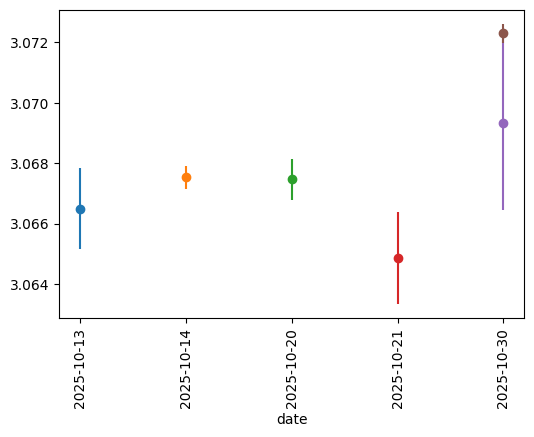

In [61]:
plotf.plot_calibration_results('1064',LDETcalibration_linear_results,metadata,gain=True)

In [1554]:
LDETcalibration_quadratic_results['1076'][8636]

In [1570]:
results = gain
df = {}

p = []
r = []
g = []
for pixel in pixels:
    runs = list(results[pixel].keys())
    if runs==[]:
        continue
    df[pixel] = {}
    for run in runs:
        gr = results[pixel][run]['value']
        g.append(g)
        p.append(int(pixel))
        r.append(run)

In [1565]:
LDETcalibration_quadratic_results['1076'][8636].params['m'].correl['b']

-0.9742456281203034

In [1560]:
cov = LDETcalibration_quadratic_results['1076'][8636].covar

array([[ 2.19178768e-05, -6.82812730e-03, -1.52135669e-08],
       [-6.82812730e-03,  2.24113391e+00,  4.61827434e-06],
       [-1.52135669e-08,  4.61827434e-06,  1.07025561e-11]])

In [1573]:
LDETcalibration_quadratic_results['1076'][8636].chisqr

3.1306711907598395

In [1561]:
std_devs = np.sqrt(np.diag(cov))

# Create a diagonal matrix of the inverse of standard deviations
# The 1/ part takes the reciprocal
inv_std_devs = np.diag(1 / std_devs)

# Calculate the correlation matrix: R = D⁻¹ * Σ * D⁻¹
# where Σ is the covariance matrix and D is the diagonal matrix of standard deviations
correlation_matrix = inv_std_devs @ cov @ inv_std_devs
print(correlation_matrix)

[[ 1.         -0.97424563 -0.99331742]
 [-0.97424563  1.          0.9429791 ]
 [-0.99331742  0.9429791   1.        ]]


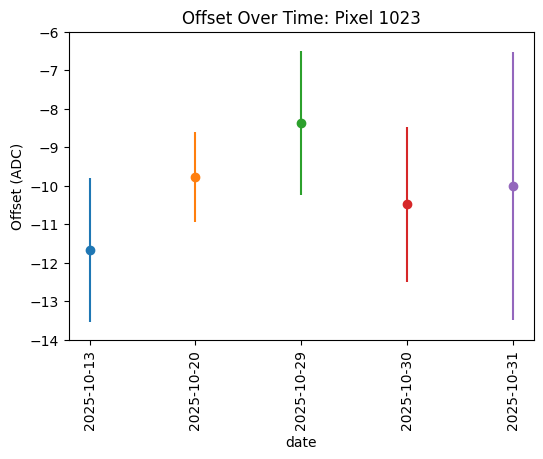

In [1512]:
plotf.plot_calibration_results('1023',LDETcalibration_linear_results,metadata,offset=True,
                               title='Offset Over Time: Pixel 1023',ylabel='Offset (ADC)',
                              bottom_ylim=-14,top_ylim=-6)

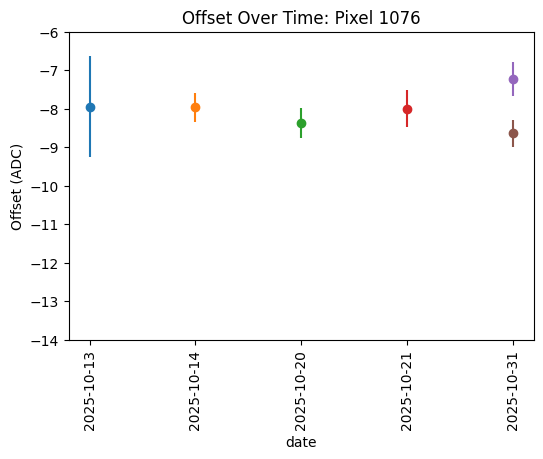

In [1513]:
plotf.plot_calibration_results('1076',LDETcalibration_linear_results,metadata,offset=True,
                               title='Offset Over Time: Pixel 1076',ylabel='Offset (ADC)',
                              bottom_ylim=-14,top_ylim=-6)

In [62]:
# pixels = list(LDETgain.keys())
# for pixel in pixels:
#     runs = list(LDETgain[pixel].keys())
#     print(pixel,runs)

In [40]:
keys = list(gain.keys())
andrew_results = {}
for i in range(len(keys)):
    andrew_results[keys[i]] = {}
    
    andrew_results[keys[i]]['gain'] = gain[keys[i]][list(gain[keys[i]].keys())[0]]['value']
    andrew_results[keys[i]]['gain error'] = gain[keys[i]][list(gain[keys[i]].keys())[0]]['error']
    
    andrew_results[keys[i]]['offset'] = offset[keys[i]][list(gain[keys[i]].keys())[0]]['value']
    andrew_results[keys[i]]['offset error'] = offset[keys[i]][list(gain[keys[i]].keys())[0]]['error']
    
    andrew_results[keys[i]]['run number'] = list(gain[keys[i]].keys())[0]

In [41]:
keys = list(LDETgain.keys())
for i in range(len(keys)):
    andrew_results[keys[i]] = {}
    andrew_results[keys[i]]['gain'] = LDETgain[keys[i]][list(LDETgain[keys[i]].keys())[0]]['value']
    andrew_results[keys[i]]['gain error'] = LDETgain[keys[i]][list(LDETgain[keys[i]].keys())[0]]['error']
    
    andrew_results[keys[i]]['offset'] = LDEToffset[keys[i]][list(LDETgain[keys[i]].keys())[0]]['value']
    andrew_results[keys[i]]['offset error'] = LDEToffset[keys[i]][list(LDETgain[keys[i]].keys())[0]]['error']
    andrew_results[keys[i]]['run number'] = list(LDETgain[keys[i]].keys())[0]

In [45]:
import json

In [48]:
with open("calibrated_pixels_andrew.json", "w") as json_file:
    json.dump(andrew_results, json_file, indent=4,default=int)

In [49]:
len(andrew_results)

129

In [127]:
calibration_quadratic_results['11'][8655].covar

array([[ 3.97400766e-06, -1.23244414e-03, -2.77806805e-09],
       [-1.23244414e-03,  4.16346865e-01,  8.24960226e-07],
       [-2.77806805e-09,  8.24960226e-07,  1.98386218e-12]])

In [63]:
gain = bf.get_calibration_fit_params(calibration_linear_results,gain=True)
offset = bf.get_calibration_fit_params(calibration_linear_results,offset=True)

In [64]:
LDETgain = bf.get_calibration_fit_params(LDETcalibration_linear_results,gain=True)
LDEToffset = bf.get_calibration_fit_params(LDETcalibration_linear_results,offset=True)

In [65]:
quad = bf.get_calibration_fit_params(calibration_quadratic_results,quad=True)
LDETquad = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,quad=True)

In [66]:
quad_gain = bf.get_calibration_fit_params(calibration_quadratic_results,gain=True)
LDETquad_gain = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,gain=True)
quad_offset = bf.get_calibration_fit_params(calibration_quadratic_results,offset=True)
LDETquad_offset = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,offset=True)

In [67]:
average_gain, average_gain_error, gain_std = bf.get_calibration_param_props(gain)
average_gain_weighted, average_gain_error_weighted, gain_std_weighted = bf.get_calibration_param_props(gain,weighted=True)

average_offset, average_offset_error, offset_std = bf.get_calibration_param_props(offset)
average_offset_weighted, average_offset_error_weighted, offset_std_weighted = bf.get_calibration_param_props(offset,weighted=True)

In [120]:
offset['11']

{8655: {'value': -1.2042300237215435, 'error': 0.25496804467633566},
 8709: {'value': -1.055028873716011, 'error': 0.4970097645487867},
 8855: {'value': -1.2924084244078113, 'error': 0.25199288952432525}}

In [68]:
LDETaverage_gain, LDETaverage_gain_error, LDETgain_std = bf.get_calibration_param_props(LDETgain)
LDETaverage_gain_weighted, LDETaverage_gain_error_weighted, LDETgain_std_weighted = bf.get_calibration_param_props(LDETgain,weighted=True)

LDETaverage_offset, LDETaverage_offset_error, LDEToffset_std = bf.get_calibration_param_props(LDEToffset)
LDETaverage_offset_weighted, LDETaverage_offset_error_weighted, LDEToffset_std_weighted = bf.get_calibration_param_props(LDEToffset,weighted=True)

In [69]:
average_quad_weighted, average_quad_error_weighted, quad_std_weighted = bf.get_calibration_param_props(quad,weighted=True)
LDETaverage_quad_weighted, LDETaverage_quad_error_weighted, LDETquad_std_weighted = bf.get_calibration_param_props(LDETquad,weighted=True)

In [103]:
average_quad_gain_weighted, average_quad_gain_error_weighted, quad_gain_std_weighted = bf.get_calibration_param_props(quad_gain,weighted=True)
LDETaverage_quad_gain_weighted, LDETaverage_quad_gain_error_weighted, LDETquad_gain_std_weighted = bf.get_calibration_param_props(LDETquad_gain,weighted=True)

average_quad_offset_weighted, average_quad_offset_error_weighted, quad_offset_std_weighted = bf.get_calibration_param_props(quad_offset,weighted=True)
LDETaverage_quad_offset_weighted, LDETaverage_quad_offset_error_weighted, LDETquad_offset_std_weighted = bf.get_calibration_param_props(LDETquad_offset,weighted=True)

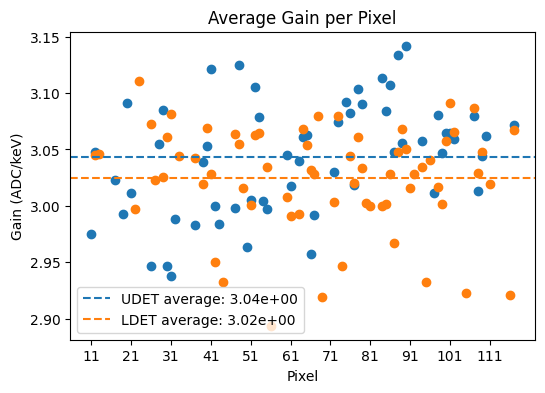

In [1316]:
plotf.plot_calibration_param_props(average_gain_weighted,LDETparam_prop_df=LDETaverage_gain_weighted,title='Average Gain per Pixel',ylabel='Gain (ADC/keV)')




In [85]:
gain_std_weighted['75']

0.006367755151957958

In [115]:
# plotf.plot_calibration_param_props(quad_gain_std_weighted,yscale='log',LDETparam_prop_df=LDETquad_gain_std_weighted,
#                                    title='Average Gain Variation per Pixel',ylabel='Variation (ADC/keV)',
#                                    bottom_ylim=4e-5,top_ylim=8e-2)

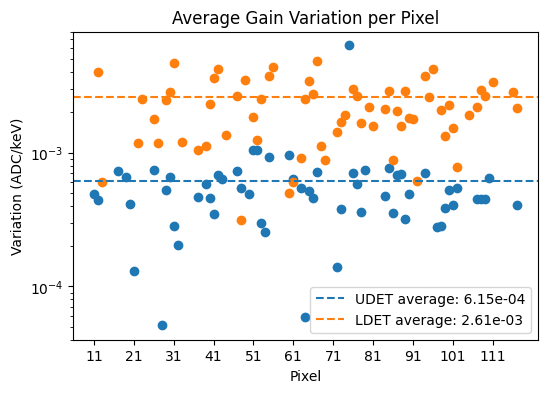

In [110]:
plotf.plot_calibration_param_props(gain_std_weighted,yscale='log',LDETparam_prop_df=LDETgain_std_weighted,
                                   title='Average Gain Variation per Pixel',ylabel='Variation (ADC/keV)',
                                   bottom_ylim=4e-5,top_ylim=8e-3)

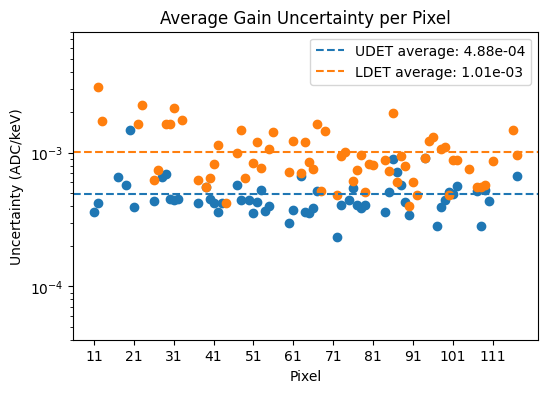

In [111]:
plotf.plot_calibration_param_props(average_gain_error,yscale='log',LDETparam_prop_df=LDETaverage_gain_error,
                                   title='Average Gain Uncertainty per Pixel',ylabel='Uncertainty (ADC/keV)',
                                   bottom_ylim=4e-5,top_ylim=8e-3)

In [116]:
# plotf.plot_calibration_param_props(average_quad_gain_error_weighted,yscale='log',LDETparam_prop_df=LDETaverage_quad_gain_error_weighted,
#                                    title='Average Gain Uncertainty per Pixel',ylabel='Uncertainty (ADC/keV)',
#                                    bottom_ylim=5e-4,top_ylim=1)

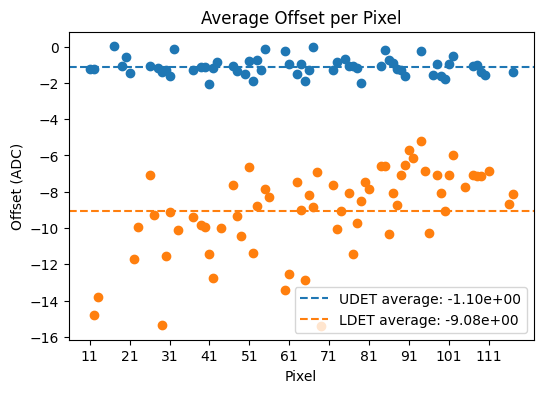

In [92]:
plotf.plot_calibration_param_props(average_offset_weighted,LDETparam_prop_df=LDETaverage_offset_weighted,title='Average Offset per Pixel',ylabel='Offset (ADC)')



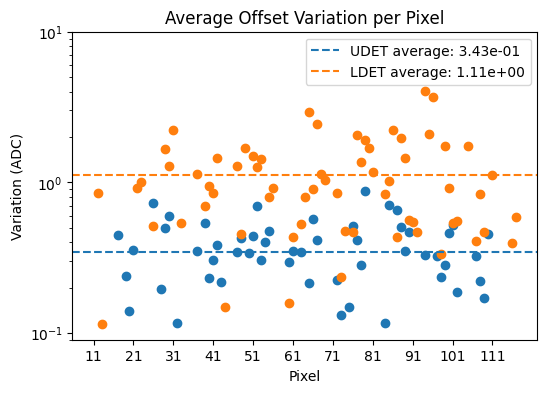

In [94]:
plotf.plot_calibration_param_props(offset_std_weighted,yscale='log',LDETparam_prop_df=LDEToffset_std_weighted,
                                   title='Average Offset Variation per Pixel',ylabel='Variation (ADC)',
                                   bottom_ylim=9e-2,top_ylim=10)

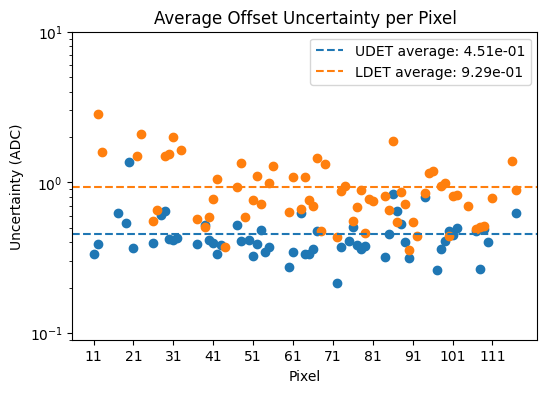

In [118]:
plotf.plot_calibration_param_props(average_offset_error,yscale='log',LDETparam_prop_df=LDETaverage_offset_error,
                                   title='Average Offset Uncertainty per Pixel',ylabel='Uncertainty (ADC)',
                                   bottom_ylim=9e-2,top_ylim=10)

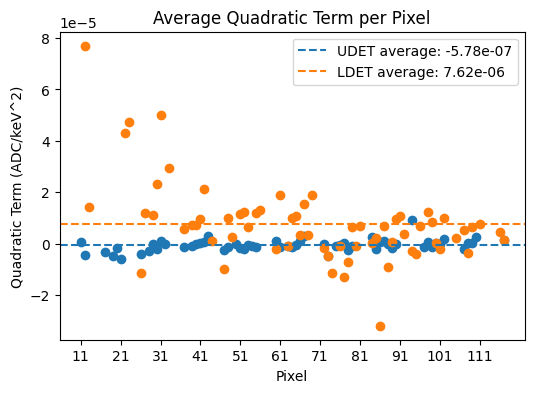

In [96]:
plotf.plot_calibration_param_props(average_quad_weighted,LDETparam_prop_df=LDETaverage_quad_weighted,title='Average Quadratic Term per Pixel',ylabel='Quadratic Term (ADC/keV^2)')



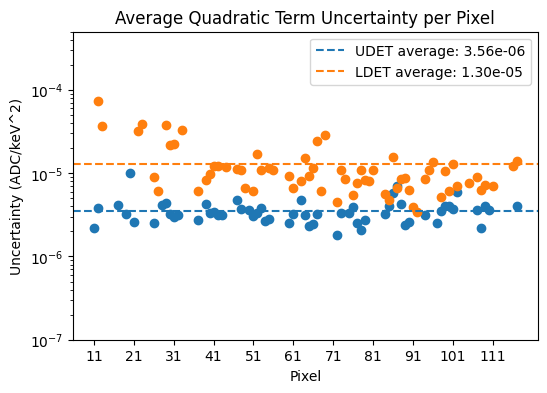

In [101]:
plotf.plot_calibration_param_props(average_quad_error_weighted,yscale='log',LDETparam_prop_df=LDETaverage_quad_error_weighted,
                                   title='Average Quadratic Term Uncertainty per Pixel',ylabel='Uncertainty (ADC/keV^2)',
                                   bottom_ylim=1e-7,top_ylim=5e-4)




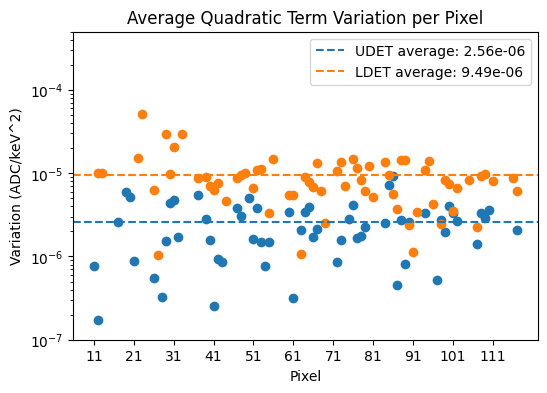

In [102]:
plotf.plot_calibration_param_props(quad_std_weighted,yscale='log',LDETparam_prop_df=LDETquad_std_weighted,
                                   title='Average Quadratic Term Variation per Pixel',ylabel='Variation (ADC/keV^2)',
                                   bottom_ylim=1e-7,top_ylim=5e-4)


In [1293]:
for key,value in LDETaverage_offset_error.items():
    if value>3:
        print(key,value)

1020 41.39943069230812


In [1536]:
pixel = '1076'
runs = list(LDEToffset[pixel].keys())
for run in runs:
    print(LDEToffset[pixel][run]['error']/LDETgain[pixel][run]['value'])

0.4309916849553007
0.1211996211344192
0.12829772285548546
0.16030945332094837
0.1416065330475903
0.11599705097274644


1012
1020
1022
1023
1031
1069
1086


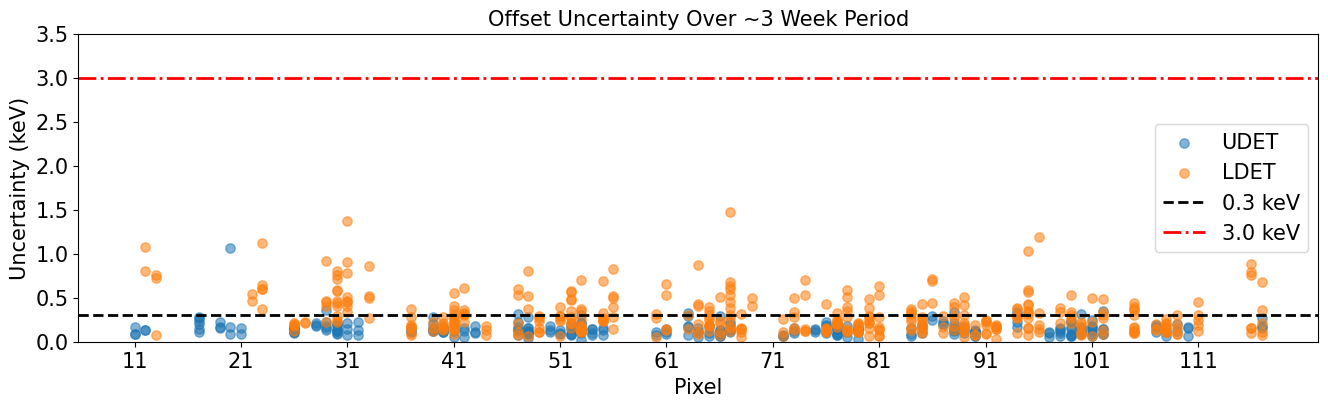

In [160]:
nrows,ncols=1,1
py.figure(figsize=((16)*ncols,(4)*nrows))
ax=py.subplot(nrows,ncols,1)

pixels = list(offset.keys())
int_pixels = list(map(int, pixels))
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        runs = list(offset[pixel].keys())
        all_uncert = []
        for run in runs:
            uncert = offset[pixel][run]['error']/gain[pixel][run]['value']
            all_uncert.append(uncert)
            if uncert>0.5:
                # print(pixel,run,uncert)
                pass
            if pixel=='11' and run==8655:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55,label='UDET')
            else:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55)
        if any(value<0.3 for value in all_uncert):
            pass
        else:
            print(pixel)
pixels = list(LDEToffset.keys())
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        runs = list(LDEToffset[pixel].keys())
        LDETall_uncert = []
        for run in runs:
            uncert = LDEToffset[pixel][run]['error']/LDETgain[pixel][run]['value']
            LDETall_uncert.append(uncert)
            if uncert>2:
                # print(pixel,run,uncert)
                pass
            if pixel=='1012' and run==8719:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55,label='LDET')
            else:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55)
        if any(value<0.3 for value in LDETall_uncert):
            pass
        else:
            print(pixel)
ax.set_xticks(range(min(int_pixels),max(int_pixels),10))
ax.set_ylim(0,3.5)
ax.axhline(0.3,color = 'black', linestyle='dashed',label = '0.3 keV',linewidth=2)
ax.axhline(3,color = 'red', linestyle='dashdot',label = '3.0 keV',linewidth=2)
ax.set_xlabel('Pixel',fontsize=15)
ax.set_ylabel('Uncertainty (keV)',fontsize=15)
ax.set_title('Offset Uncertainty Over ~3 Week Period',fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=15)
plt.show()

In [1358]:
LDEToffset['1012']

{8719: {'value': -13.639216001726547, 'error': 3.2860278221069557},
 8829: {'value': -15.399724739586103, 'error': 2.4400162348763}}

In [162]:
y = np.arange(0,1600)
diff = {}
pixels = list(gain.keys())
for pixel in pixels:
    diff[i] = {}
    runs = gain.keys
    for run in cal_result[i]['m'].keys():
        quad = cal_result[i]['q1'][j]*y**2 +cal_result[i]['q2'][j]*y + cal_result[i]['q3'][j]
        lin = cal_result[i]['m'][j]*y + cal_result[i]['b'][j]
        full_diff = quad-lin
        if cal_result[i]['q1'][j]>0:
            diff[i][j] = np.min(full_diff)
        if cal_result[i]['q1'][j]<0:
            diff[i][j] = np.max(full_diff)

NameError: name 'cal_result' is not defined

In [163]:
y = np.arange(0,1600)
pixels = list(offset.keys())
int_pixels = list(map(int, pixels))
diff = {}
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        diff[pixel] = {}
        runs = list(offset[pixel].keys())
        all_uncert = []
        for run in runs:
            quadratic = quad[pixel][run]['value']*y**2 + quad_gain[pixel][run]['value']*y + quad_offset[pixel][run]['value']
            lin = gain[pixel][run]['value']*y + offset[pixel][run]['value']
            full_diff = quadratic-lin
            if quad[pixel][run]['value']>0:
                diff[pixel][run] = np.min(full_diff)/gain[pixel][run]['value']
            if quad[pixel][run]['value']<0:
                diff[pixel][run] = np.max(full_diff)/gain[pixel][run]['value']

In [164]:
y = np.arange(0,1600)
pixels = list(LDEToffset.keys())
LDETint_pixels = list(map(int, pixels))
LDETdiff = {}
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        LDETdiff[pixel] = {}
        runs = list(LDEToffset[pixel].keys())
        all_uncert = []
        for run in runs:
            quadratic = LDETquad[pixel][run]['value']*y**2 + LDETquad_gain[pixel][run]['value']*y + LDETquad_offset[pixel][run]['value']
            lin = LDETgain[pixel][run]['value']*y + LDEToffset[pixel][run]['value']
            full_diff = quadratic-lin
            if LDETquad[pixel][run]['value']>0:
                LDETdiff[pixel][run] = np.min(full_diff)/LDETgain[pixel][run]['value']
            if LDETquad[pixel][run]['value']<0:
                LDETdiff[pixel][run] = np.max(full_diff)/LDETgain[pixel][run]['value']

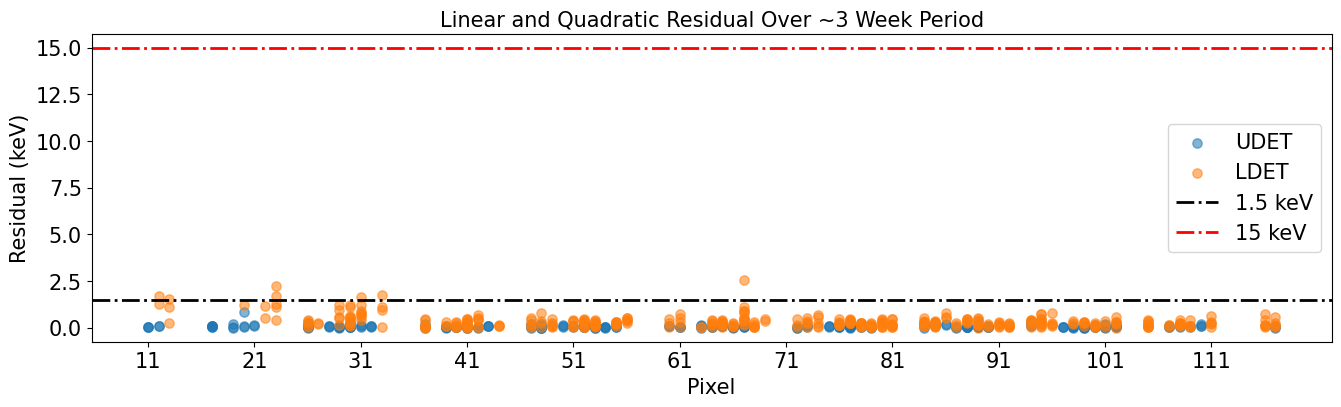

In [167]:
nrows,ncols=1,1
py.figure(figsize=((16)*ncols,(4)*nrows))
ax=py.subplot(nrows,ncols,1)

pixels = list(diff.keys())
int_pixels = list(map(int, pixels))
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        runs = list(diff[pixel].keys())
        all_uncert = []
        for run in runs:
            uncert = np.abs(diff[pixel][run])
            all_uncert.append(uncert)
            if pixel=='11' and run==8655:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55,label='UDET')
            else:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55)
        if any(value<1.5 for value in all_uncert):
            pass
        else:
            print(pixel)
pixels = list(LDETdiff.keys())
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        runs = list(LDETdiff[pixel].keys())
        LDETall_uncert = []
        for run in runs:
            uncert = np.abs(LDETdiff[pixel][run])
            LDETall_uncert.append(uncert)
            if pixel=='1012' and run==8719:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55,label='LDET')
            else:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55)
        if any(value<1.5 for value in LDETall_uncert):
            pass
        else:
            print(pixel)
ax.set_xticks(range(min(int_pixels),max(int_pixels),10))
# ax.set_ylim(-0.1,20)
# ax.axhline(0.3,color = 'black', linestyle='dashed',label = '0.3 keV',linewidth=2)
ax.axhline(1.5,color = 'black', linestyle='dashdot',label = '1.5 keV',linewidth=2)
ax.axhline(15,color = 'red', linestyle='dashdot',label = '15 keV',linewidth=2)
ax.set_xlabel('Pixel',fontsize=15)
ax.set_ylabel('Residual (keV)',fontsize=15)
ax.set_title('Linear and Quadratic Residual Over ~3 Week Period',fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=15)
plt.show()

In [122]:
1e-5/56

1.7857142857142858e-07

In [1545]:
with open('DatabaseFiles/Pixels/SourcePixelTracking.csv') as f:
    csv.DictReader(f)
    pix_source = pd.read_csv(f)

,Pixel,run_numbers,BC,Source,Centered
0,11,8655,55,Bi-207-9177 Y2-744,Yes
1,11,8709,55,Bi-207-9177 Y2-744,Yes
2,11,8855,55,Bi-207-9177 Y2-744,Yes


In [1551]:
pix_source

,Pixel,run_numbers,BC,Source,Centered
0,11,8655,55,Bi-207-9177 Y2-744,Yes
1,11,8709,55,Bi-207-9177 Y2-744,Yes
2,11,8855,55,Bi-207-9177 Y2-744,Yes
3,12,8646,80,Bi-207-9177 Y2-744,Yes
4,12,8848,80,Bi-207-9177 Y2-744,Yes
...,...,...,...,...,...
247,110,8687,72,Bi-207-8890 X5-302,Yes
248,110,8842,72,Bi-207-8890 X5-302,Yes
249,117,8651,71,Bi-207-8890 X5-302,No
250,117,8705,71,Bi-207-8890 X5-302,No


In [1549]:
detector = ['UDET: Goop!']*len(pix_source)